This is the notebook for plotting correlations among different neurons and different behaviors as a function of bin size.
Correlations of different neurons with each other are plotted in the last section

In [41]:
import numpy as np
import h5py
import csv
import math
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import style
from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
import pandas as pd
import seaborn as sns
import copy
import scipy
import Functions.Binning as Bin
import Functions.Regressors as Rss
import importlib
import Functions.AllFunctions as AllF
import matplotlib.gridspec as gridspec

In [42]:
h5 = h5py.File('MegaData7_7worms_V5.h5', 'r')

In [43]:
L= h5['data_sets_info/lowercam_length']
n_title = [s.decode('utf-8') for s in list(h5['data_sets_info/neuron_names'])]
MegaData0 = np.copy(h5['data/dataraw'])
MegaData0[np.isnan(MegaData0)]=0

In [44]:
MegaData =copy.deepcopy(MegaData0)

In [45]:
smooth=True
numW=7

In [46]:
for i in range(55):
    if i >12 and not (i in [27,28,39,40]):
        MegaData[5,:243,i] = 0
        MegaData0[5,:243,i] = 0


for i in range(55):
    MegaData[6,L[6]:,i] = 0
    MegaData0[6,L[6]:,i] = 0

In [47]:
sm = [2,2,2,3,4,3,3]
g=[5,5,5,7,10,7,7]
if smooth:
    for d in range(7):
        for i in range(55):
            if not (i in [10,11,12]):
                MegaData[d,:L[d],i] = Bin.smooth_vec_long(MegaData0[d,:L[d],i],sm[d],g[d])

In [38]:
MegaData_int_sm =copy.deepcopy(MegaData)

for d in range(5):
    sec0 = AllF.closest_index(MegaData0[d,:,12],2)
    sec60 = AllF.closest_index(MegaData0[d,:,12],422)
    interval = int(sec60-sec0)
    rowsArr_float = copy.deepcopy(MegaData[d,:L[d],:])
    for i in [0,1,2,3,4,5,6,7,8,27,28,39,40]:   
        if d>0 or not(i in [3,5]):
            MegaData_int_sm[d,:L[d],i] = AllF.compute_everymin_maxmin(rowsArr_float[:L[d],i],minlength=int(interval))
        

NameError: name 'closest_index' is not defined

In [48]:
index_start=np.zeros(numW)
index_end=np.zeros(numW)
for d in range(numW):
    index_start[d]= int(AllF.closest_index(MegaData0[d,:L[d],12],IAA_int[d,1]))
    index_end[d]= int(AllF.closest_index(MegaData0[d,:L[d],12],NN_int[d,0]))
Interv_length = index_end-index_start
Lnew = np.max(Interv_length)
shape = np.shape(MegaData0)
print(shape[0],Lnew,shape[2])
MegaDataSlice = np.zeros((shape[0],int(Lnew),shape[2]))
for d in range(numW):
    MegaDataSlice[d,:int(Interv_length[d]),:] = MegaData[d,int(index_start[d]):int(index_end[d]),:]

MegaData =copy.deepcopy(MegaDataSlice)

8 848.0 60


In [30]:
#correcting OdorLabels
#intervals of IAA and nonanone
IAA_int = np.zeros((numW,4))
NN_int = np.zeros((numW,4))
IAA_int[0,:] = [210,690,1775,2255]
IAA_int[1,:] = [210,690,1775,2255]
IAA_int[2,:] = [210,690,1775,2255]
IAA_int[3,:] = [210,690,1775,2255]
IAA_int[4,:] = [1,500,1575,2055]
NN_int[0,:] = [997,1477,2555,3040]
NN_int[1,:] = [997,1477,2555,3040]
NN_int[2,:] = [997,1477,2555,3040]
NN_int[3,:] = [997,1477,2555,3040]
NN_int[4,:] = [797,1277,2350,2840]

NN_int[5,:] = [957,1437,2520,3000]
IAA_int[5,:] = [177,657,1737,2240]
NN_int[6,:] = [1080,1560,2560,3000]
IAA_int[6,:] = [300,780,1780,2260]


d: 0


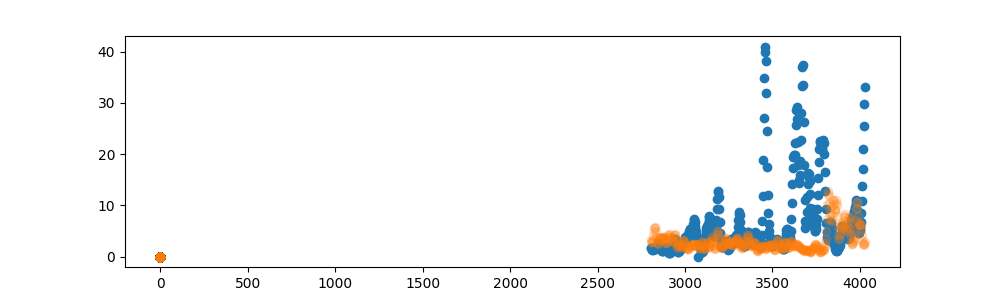

ValueError: could not broadcast input array from shape (848,) into shape (2756,)

In [49]:
#Define velocity threshold for forward and backward movement
#plot velocity of head
forward_vec= np.zeros((numW,8100))
Dorsal_vec = np.zeros((numW,8100))
ventral_vec = np.zeros((numW,8100))
backward_vec= np.zeros((numW,8100))
speed_vec= np.zeros((numW,8100))
turn_vec= np.zeros((numW,8100))

pix = [1, 0.001923, 0.002, 0.001923, 0.001923, 0.002222, 0.002222]
velchoice=16
thresh_bin0 = [0.06,6,6,12,10,12,12]
thresh_bin = [pix[w]*thresh_bin0[w] for w in range(numW)]
threshPos0 = [0.1,2.6,2,2.4,4.5,1.5,2]#[0.6,3.6,8.5,6.3,9.3,5.3]#based  on top 30 or 40percent percentile of V16
threshPos = [pix[w]*threshPos0[w] for w in range(numW)]
threshNeg0 =[-0.1,-1.6,-0.3,-1,-0.7,-0.5,-1.5]#[-0.06,-2.6,-2.3,-2.5,-3.1,-2.9]#based on 30 percent of V16
threshNeg = [pix[w]*threshNeg0[w] for w in range(numW)]
speedthresh0 = [1,6,16,11,16,10,10]
speedthresh = [pix[w]*speedthresh0[w] for w in range(numW)]
head_thresh0 = [7,13,30,23,36,29,25]#based on 0.25 top percentie of velocity 25
head_thresh = [pix[w]*head_thresh0[w] for w in range(numW)]
for d in range(numW):
    print("d: "+str(d))
    rowsArr_float = copy.deepcopy(MegaData[d,:L[d],:])
    Vel5 = rowsArr_float[:,velchoice]
    
    VelH = rowsArr_float[:,22]
    fig = plt.figure(figsize=(10,3))
    ax = fig.add_subplot()
    VelMag = rowsArr_float[:,15]
    VelH_mag = rowsArr_float[:,25]
    ax.scatter(rowsArr_float[:,11],rowsArr_float[:,21])
    ax.scatter(rowsArr_float[:,11],VelH_mag,alpha=0.2 )
    plt.show()

    thet = rowsArr_float[:,46]#mid body angular velocity
    forward_vec[d,:L[d]] = Vel5 > threshPos[d]
    backward_vec[d,:L[d]] = Vel5 < threshNeg[d]
    speed_vec[d,:L[d]] = VelMag > speedthresh[d]
    turn_vec[d,:L[d]]  = thet > 10 #moments where the worm takes a turn
    Dorsal_vec = VelH < - head_thresh[d]
    ventral_vec = VelH > head_thresh[d]

In [50]:
# define bins of different variables. and number of bins for each recording
m=1
max_neurons=13
neurons = [0,1,2,3,4,5,6,7,8,27,28,39,40]# indices corresponding to neurons or neurites in 3rd axis of MegaData matrix
thresh_bin = [0.6,6,6,12,10,12]
bin_coeff = [0.5,1,2,3,4,5,6,12]
y_labels = ['120','60', '30', '20', '15', '12', '10', '5','2']



In [53]:
L=[int(l) for l in Interv_length]

In [54]:
# print length of recordings for each worm
for d in range(numW):
    print("Worm"+str(d)+" :")
    print(str((MegaData0[d,L[d]-2,12]-MegaData0[d,0,12])/60)+' min')


Worm0 :
5.088294634222985 min
Worm1 :
5.08829463471969 min
Worm2 :
5.088294634222985 min
Worm3 :
5.097388783593972 min
Worm4 :
4.941316889226437 min
Worm5 :
4.979525823146105 min
Worm6 :
4.979525760000013 min


In [38]:
#print time difference between consecutive volumes in neuronal recordings for each worm
for d in range(numW):
    print("Worm"+str(d)+" :")
    print(str((MegaData0[d,10,12]-MegaData0[d,9,12]))+' sec')

Worm0 :
0.7002239227294922 sec
Worm1 :
0.7002239227294922 sec
Worm2 :
0.7002239227294922 sec
Worm3 :
0.5255041122436523 sec
Worm4 :
0.3504481315612793 sec
Worm5 :
0.49547529220581055 sec
Worm6 :
0.49547520000021894 sec


In [35]:

corr_neuronsRI_ind_Vel1 = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_Vel2 = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_curv = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_acc = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_head = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_theta = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_turn = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_speed = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_Back = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_Forward = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_BackFreq = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_ForwardFreq = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_head = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_headAngle = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind_headAngle2 = np.zeros((len(bin_coeff),numW,max_neurons))
corr_neuronsRI_ind= np.zeros((len(bin_coeff),numW,max_neurons,max_neurons))

In [36]:
importlib.reload(Bin)

<module 'Functions.Binning' from '/mnt/DATA/Mahsa/movies/LongRecordings/codes/Cluster/Functions/Binning.py'>

In [56]:
bin_coeff =[1,2,3,4,5,6,12]# [0.5,1,2,3,4,5,6,12]
for m0 in range(len(bin_coeff)) :
    m= bin_coeff[m0]
    b=[int(5*m),int(5*m),int(5*m),int(5*m),int(5*m),int(5*m),int(5*m)]
    #b = [int(32*m),int(50*m),int(50*m),int(50*m),int(47*m),int(53*m),int(44*m)]
    activity_bins = np.zeros((numW,max_neurons,np.max(b)))
    forward_bins = np.zeros((numW,np.max(b)))
    Velocity_bin = np.zeros((numW,np.max(b)))
    backward_bins = np.zeros((numW,np.max(b)))
    backwardFreq_bins = np.zeros((numW,np.max(b)))
    forwardFreq_bins = np.zeros((numW,np.max(b)))
    time_bins = np.zeros((numW,np.max(b)))
    width_bins = np.zeros((numW,np.max(b)))
    odor_bins = np.zeros((numW,np.max(b)))
    speed_bins = np.zeros((numW,np.max(b)))
    acceleration_bins = np.zeros((numW,np.max(b)))
    head_bins = np.zeros((numW,np.max(b)))
    headAngle_bins = np.zeros((numW,np.max(b)))
    headAngle2_bins = np.zeros((numW,np.max(b)))
    head_bins_signed= np.zeros((numW,np.max(b)))
    speed_bins_im = np.zeros((numW,np.max(b)))
    theta_bins = np.zeros((numW,np.max(b)))
    turn_bins = np.zeros((numW,np.max(b)))
    curve_bins = np.zeros((numW,np.max(b)))
    
    ForwVelocity_bin = np.zeros((numW,np.max(b)))
    BackwVelocity_bin = np.zeros((numW,np.max(b)))
    
    time2bin = np.zeros((numW,np.max(b)))
    width2bin = np.zeros((numW,np.max(b)))
    #define the binned values
    for d in range(numW):
        rowsArr_float = copy.deepcopy(MegaData[d,:L[d],:])
        VelF = forward_vec[d,:L[d]]
        VelB = backward_vec[d,:L[d]]
        speed = speed_vec[d,:L[d]]
        Velthet = turn_vec[d,:L[d]]
        dfF,time_bins[d,:b[d]], mean_forward_by_bin,width_bins[d,:b[d]] = Bin.bin_and_plot(MegaData[d,:L[d],12],VelF,bins=b[d])#forward frequency
        dfB,mean_time_by_bin, mean_backward_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],VelB,bins=b[d])#backward frequency
        dfsi,mean_time_by_bin, mean_speedIm_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],speed,bins=b[d])#ratio of high speed movement
        dfTh,mean_time_by_bin, mean_theta_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],46],bins=b[d])#average theta
        dfC,mean_time_by_bin, mean_curve_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],26],bins=b[d])#average head curvature
        dfA,mean_time_by_bin, mean_acc_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],48],bins=b[d])#average acceleration
        dfVcen,mean_time_by_bin, mean_VcenSigned_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],42],bins=b[d])#mean velocity
        
        dfTh,mean_time_by_bin, mean_headV_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],25],bins=b[d])#head velocity
        dfTh,mean_time_by_bin, mean_headVsigned_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],22],bins=b[d])

        dfTh,mean_time_by_bin, headAngle_bins[d,:b[d]],width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],37],bins=b[d])#head angle center
        dfTh,mean_time_by_bin, headAngle2_bins[d,:b[d]],width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],38],bins=b[d])#head angle neck
            
        dfTh,mean_time_by_bin, mean_turn_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],Velthet,bins=b[d])
        dfod,time_bins[d,:b[d]], mean_odor_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],10],bins=b[d])
        dfsp,mean_time_by_bin, speed_bins[d,:b[d]],width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],15],bins=b[d])#speed value
        odor_bins[d,:b[d]] = mean_odor_by_bin
        
        theta_bins[d,:b[d]] = mean_theta_by_bin
        turn_bins[d,:b[d]] = mean_turn_by_bin
        curve_bins[d,:b[d]] = mean_curve_by_bin
        acceleration_bins[d,:b[d]] = mean_acc_by_bin
        Velocity_bin[d,:b[d]] = mean_VcenSigned_by_bin
        backwardFreq_bins[d,:b[d]] = mean_forward_by_bin
        forwardFreq_bins[d,:b[d]] = mean_backward_by_bin
        
        head_bins[d,:b[d]] = mean_headV_by_bin#interpolate_nanValues(mean_headV_by_bin,mean_headV_by_bin)
        head_bins_signed[d,:b[d]] = mean_headVsigned_by_bin#interpolate_nanValues(mean_headVsigned_by_bin,mean_headVsigned_by_bin)
        
        
        
        for j in range(max_neurons):
            n = neurons[j]
            #odor_bins[d,:b[d]],X = interpolate_nanValues(mean_odor_by_bin,mean_odor_by_bin)
            if len(np.nonzero(rowsArr_float[:,n])[0])>1:
                activity = rowsArr_float[:,n]
                activity[np.isinf(activity)] = 0     
                nonz = np.nonzero(activity)
                df2,mean_time_by_binA,activity_bins[d,j,:b[d]],width = Bin.bin_and_plot(MegaData[d,nonz[0],12],Bin.compute_vector_z_score(activity[nonz[0]]),bins=b[d])
            #save_csv(activity_bins[d,:,:b[d]],Address_savebins,m,varname='Activity_worm'+str(d))  
        rowsArr_float = copy.deepcopy(MegaData[d,:L[d],:])
        dfVcen,time2bin[d,:b[d]], mean_VcenSigned_by_bin,width2bin[d,:b[d]] = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],42],bins=b[d])#mean velocity
        for i in range(len(mean_VcenSigned_by_bin)):
            if (mean_VcenSigned_by_bin.iloc[i]) < 0:#thresh[d]*m/12:
                mean_VcenSigned_by_bin.iloc[i] = 0
        ForwVelocity_bin[d,:b[d]] = mean_VcenSigned_by_bin        
        dfVcen,mean_time_by_bin, mean_VcenSigned_by_bin,width = Bin.bin_and_plot(MegaData[d,:L[d],12],MegaData[d,:L[d],42],bins=b[d])#mean velocity
        for i in range(len(mean_VcenSigned_by_bin)):
            if m < 2:
                if (mean_VcenSigned_by_bin.iloc[i]) > 0:
                    mean_VcenSigned_by_bin.iloc[i] = 0
            elif (mean_VcenSigned_by_bin.iloc[i]) > 0:#-thresh[d]*m/12:
                mean_VcenSigned_by_bin.iloc[i] = 0 
        BackwVelocity_bin[d,:b[d]] = mean_VcenSigned_by_bin 
        for n0 in range(max_neurons):
            if d>0 or not (n0 in [3,5]):
                if d>0:
                    corr_neuronsRI_ind_Vel1[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], Velocity_bin[d,:b[d]])
                    corr_neuronsRI_ind_theta[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], theta_bins[d,:b[d]])
                    corr_neuronsRI_ind_turn[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], turn_bins[d,:b[d]])
                    corr_neuronsRI_ind_acc[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], acceleration_bins[d,:b[d]])
                corr_neuronsRI_ind_speed[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], speed_bins[d,:b[d]])                
                
                
                corr_neuronsRI_ind_curv[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], curve_bins[d,:b[d]])
                if m>0.5 or d in [1,2,3]:
                    if d>0:
                        corr_neuronsRI_ind_Back[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], BackwVelocity_bin[d,:b[d]])
                if d>0:    
                    corr_neuronsRI_ind_Forward[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], ForwVelocity_bin[d,:b[d]])
                    corr_neuronsRI_ind_ForwardFreq[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], forwardFreq_bins[d,:b[d]])
                    corr_neuronsRI_ind_BackFreq[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], backwardFreq_bins[d,:b[d]])
                corr_neuronsRI_ind_head[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], head_bins_signed[d,:b[d]])
                corr_neuronsRI_ind_headAngle[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], headAngle_bins[d,:b[d]])
                corr_neuronsRI_ind_headAngle2[m0,d,n0],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], headAngle2_bins[d,:b[d]])                
                for n1 in range(max_neurons):
                    if d>0 or not (n1 in [3,5]):
                        corr_neuronsRI_ind[m0,d,n0,n1],x = Bin.compute_2rows(activity_bins[d,n0,:b[d]], activity_bins[d,n1,:b[d]])

    '''
    save_csv(Velocity_bin,Address_savebins,m,varname='Velocity_')
    save_csv(theta_bins,Address_savebins,m,varname='AngularSpeed_theta_')
    save_csv(turn_bins,Address_savebins,m,varname='turn_')
    save_csv(curve_bins,Address_savebins,m,varname='curvature_')
    save_csv(acceleration_bins,Address_savebins,m,varname='acc_')
    save_csv(backwardFreq_bins,Address_savebins,m,varname='BackFreq_')
    save_csv(forwardFreq_bins,Address_savebins,m,varname='ForwFreq_')
    save_csv(head_bins,Address_savebins,m,varname='headspeed_')
    save_csv(head_bins_signed,Address_savebins,m,varname='headVelocity_')
    save_csv(headAngle_bins,Address_savebins,m,varname='headCenterAngle_')
    save_csv(headAngle2_bins,Address_savebins,m,varname='headNeckAngle_')
    save_csv(time_bins,Address_savebins,m,varname='time_')
    save_csv(speed_bins,Address_savebins,m,varname='Speed_')
    save_csv(width_bins,Address_savebins,m,varname='BinWidth_')
    save_csv(BackwVelocity_bin,Address_savebins,m,varname='BackVel_')
    save_csv(ForwVelocity_bin,Address_savebins,m,varname='ForwVel_')
    '''
        
if len(bin_coeff)>6:
    corr_neuronsRI_ind_Vel1tot = copy.deepcopy(corr_neuronsRI_ind_Vel1)
    corr_neuronsRI_ind_speedtot = copy.deepcopy(corr_neuronsRI_ind_speed)
    corr_neuronsRI_ind_thetatot = copy.deepcopy(corr_neuronsRI_ind_theta)
    corr_neuronsRI_ind_turntot = copy.deepcopy(corr_neuronsRI_ind_turn)
    corr_neuronsRI_ind_acctot = copy.deepcopy(corr_neuronsRI_ind_acc)
    corr_neuronsRI_ind_curvtot = copy.deepcopy(corr_neuronsRI_ind_curv)
    corr_neuronsRI_ind_Backtot = copy.deepcopy(corr_neuronsRI_ind_Back)
    corr_neuronsRI_ind_Forwardtot = copy.deepcopy(corr_neuronsRI_ind_Forward)
    corr_neuronsRI_ind_headtot = copy.deepcopy(corr_neuronsRI_ind_head)
    corr_neuronsRI_ind_ForwardFreqtot = copy.deepcopy(corr_neuronsRI_ind_ForwardFreq)
    corr_neuronsRI_ind_BackFreqtot = copy.deepcopy(corr_neuronsRI_ind_BackFreq)
    activity_bins0 = copy.deepcopy(activity_bins)
    



no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneous data
no simultaneo

In [16]:
y_labels = ['120','60', '30', '20', '15', '12', '10', '5']
x_labels = ['RIAL', 'RIAR', 'RIML', 'RIMR', 'RIBL', 'RIBR', 'sensory', 
            'nrDL', 'loopL', 'nrDR', 'loopR', 'nrVL', 'nrVR']

timebins = [120, 60, 30, 20, 15, 12, 10, 5]

In [57]:
y_labels = ['60', '30', '20', '15', '12', '10', '5']
x_labels = ['RIAL', 'RIAR', 'RIML', 'RIMR', 'RIBL', 'RIBR', 'sensory', 
            'nrDL', 'loopL', 'nrDR', 'loopR', 'nrVL', 'nrVR']

timebins = [ 60, 30, 20, 15, 12, 10, 5]

In [21]:
%matplotlib widget

# Heatmaps showing the correlations between different behaviors and neuronal or neuritic activity across various bin sizes.

0------------------------------
1------------------------------
2------------------------------
3------------------------------
4------------------------------
5------------------------------
6------------------------------


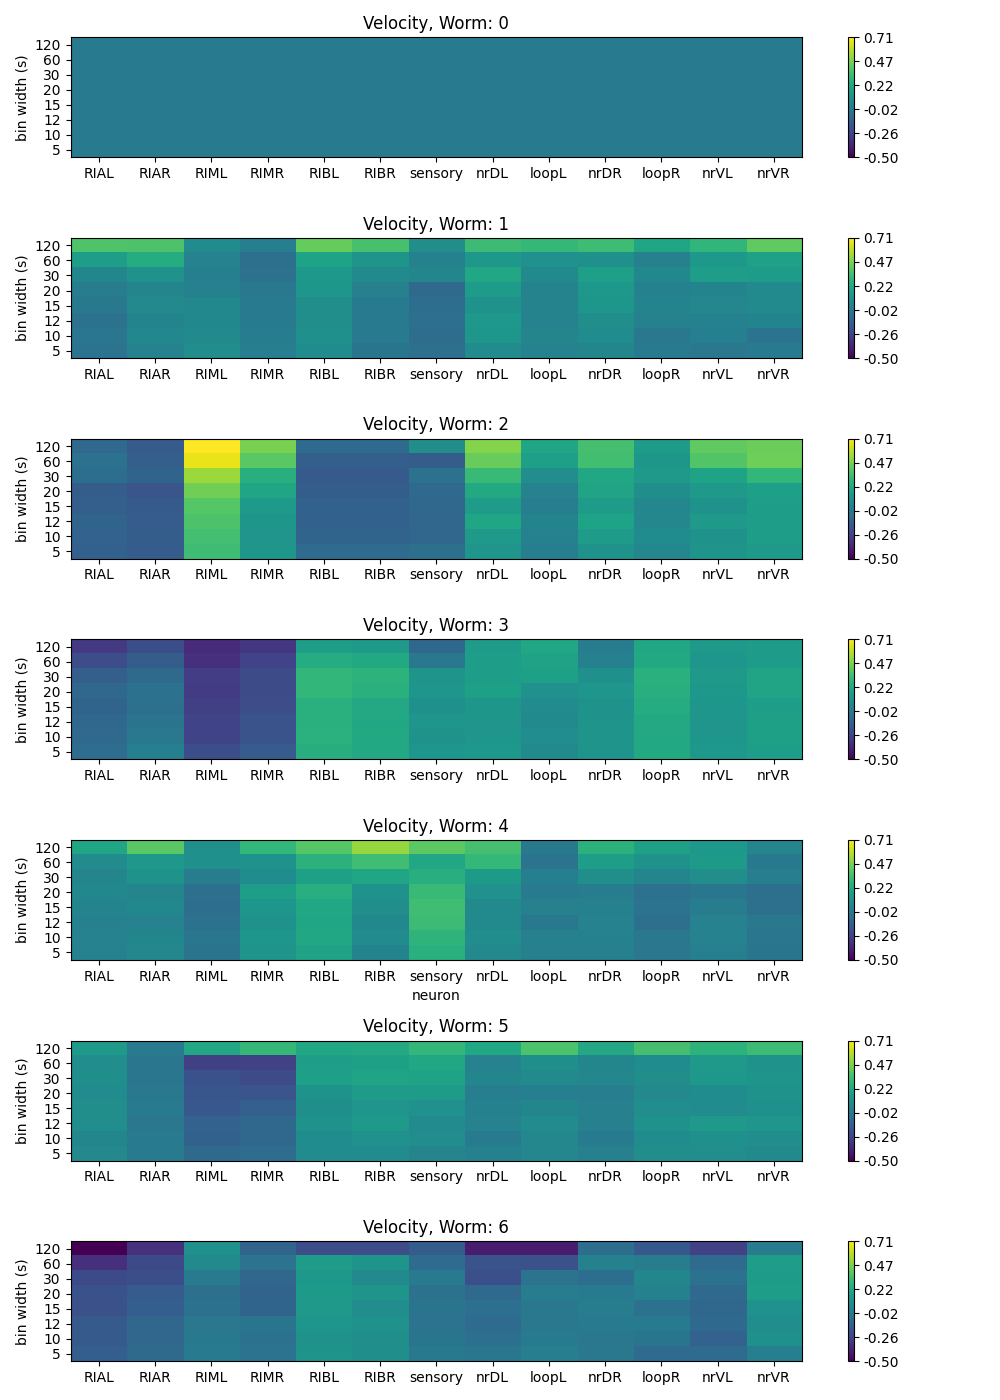

In [51]:
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = corr_neuronsRI_ind_Vel1
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    print(str(d)+'------------------------------')
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    cbar = fig.colorbar(cax1, ax=axs[d])
    cbar.set_ticks(np.linspace(all_min, all_max, num=6))
    cbar.set_ticklabels([f'{tick:.2f}' for tick in np.linspace(all_min, all_max, num=6)])
    title = 'Velocity, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()
title = title.replace(', ', '').replace(': 4', '')
fig.savefig('plotsw7/'+title +'.png')

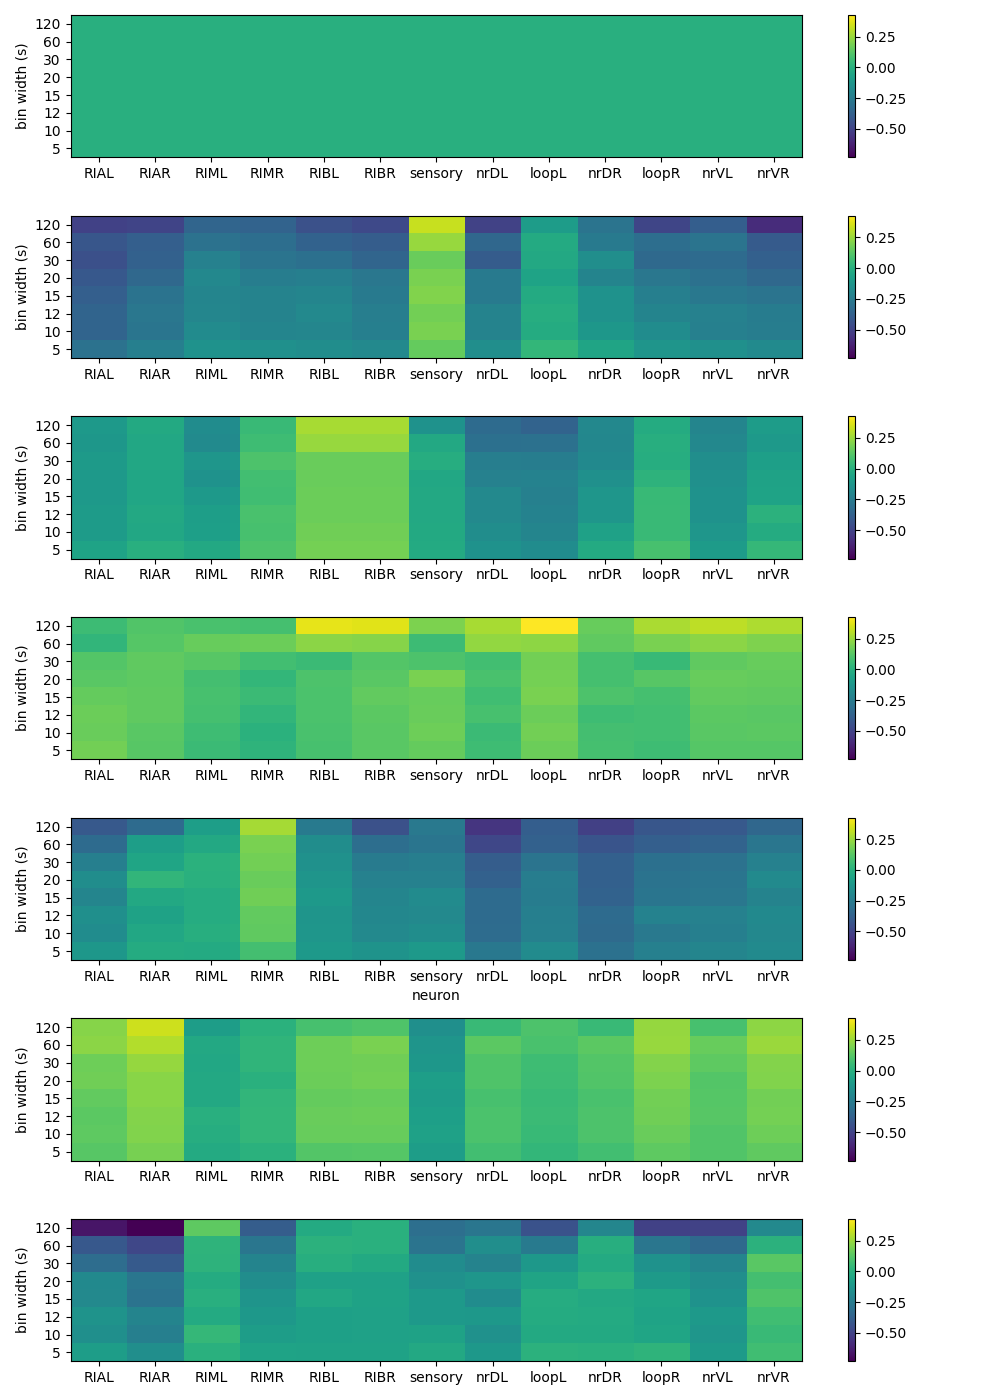

In [52]:
%matplotlib widget
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = corr_neuronsRI_ind_acc
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = corr_neuronsRI_ind_acc[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Acceleration, Worm: '+ str(d)
    #axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)
title = title.replace(', ', '').replace(': 4', '')
fig.savefig('plotsw7/'+title +'.png')
plt.tight_layout()
plt.show()

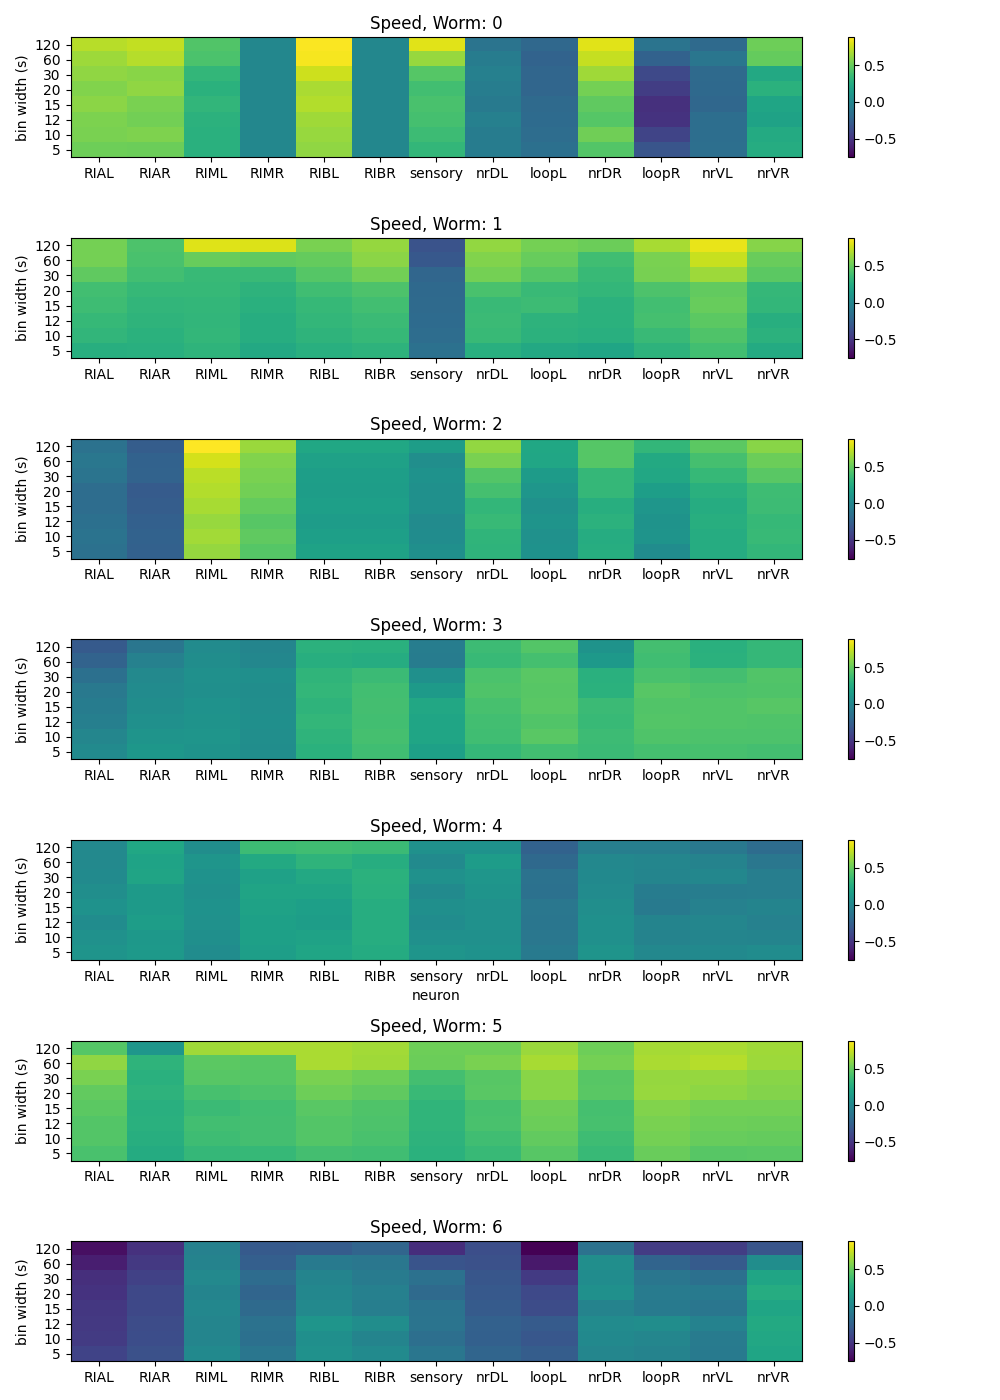

In [54]:
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_speed)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = corr_neuronsRI_ind_speed[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Speed, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)
   

plt.tight_layout()
plt.show()

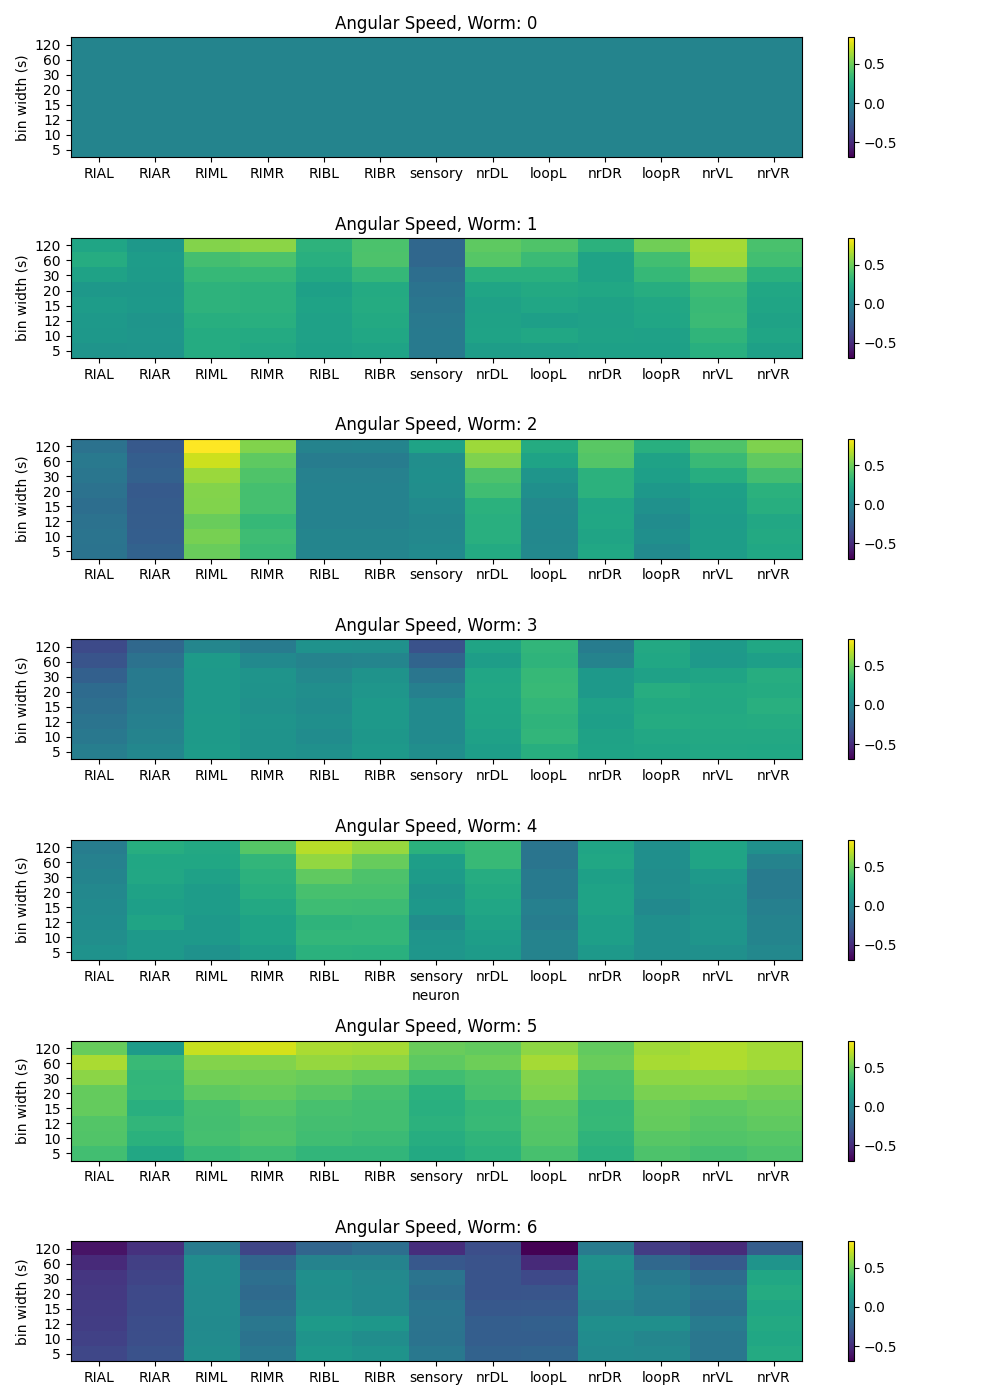

In [55]:
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_theta)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = corr_neuronsRI_ind_theta[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Angular Speed, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1499231/532442645.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(numW,1, figsize=(10, 2*numW))


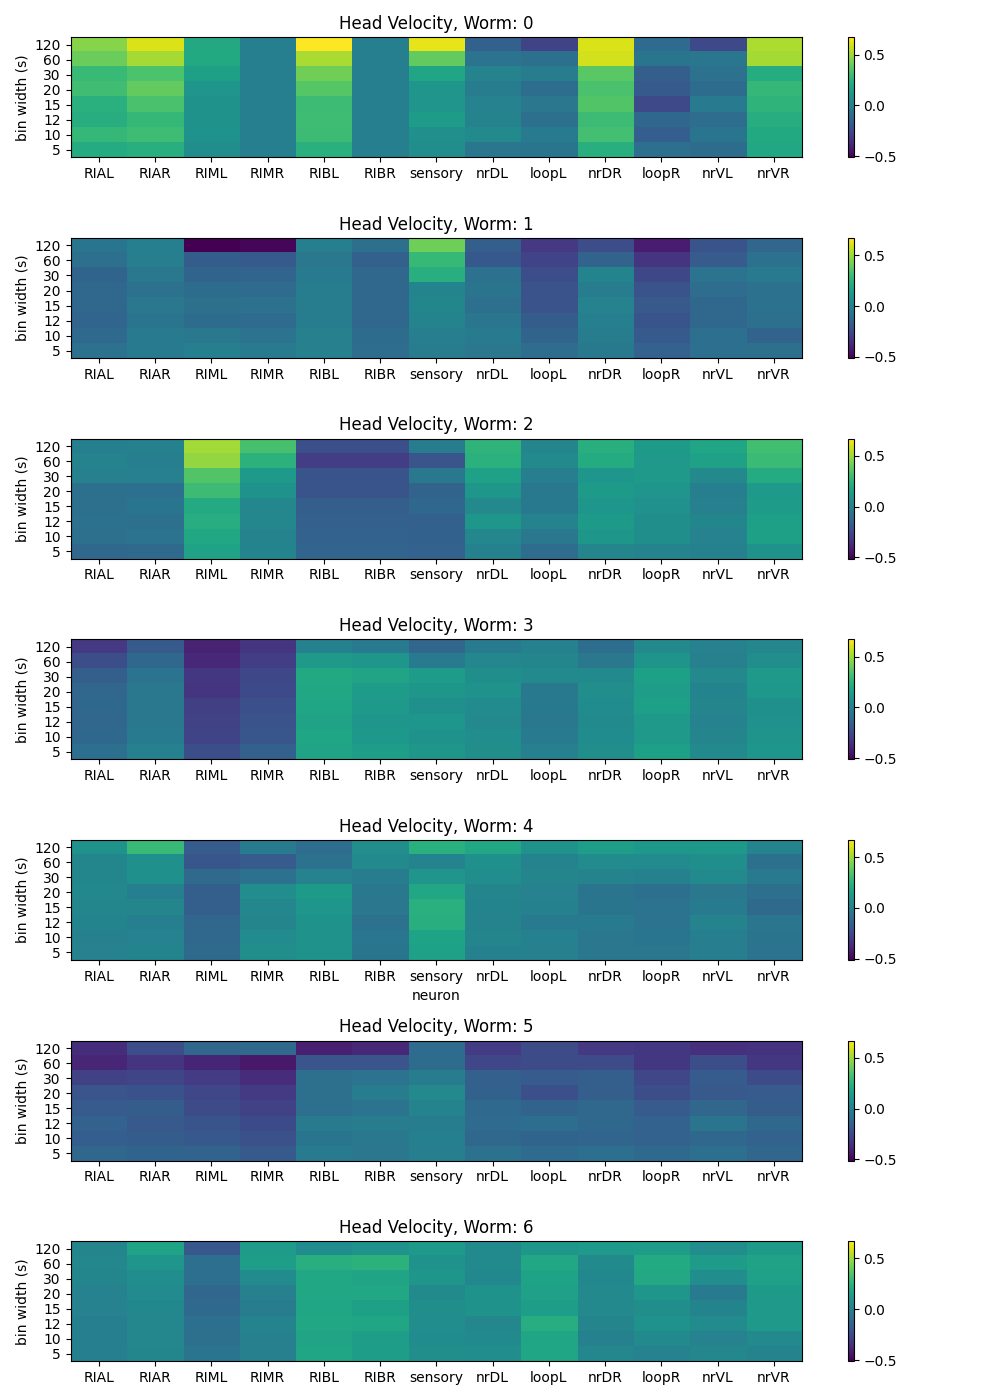

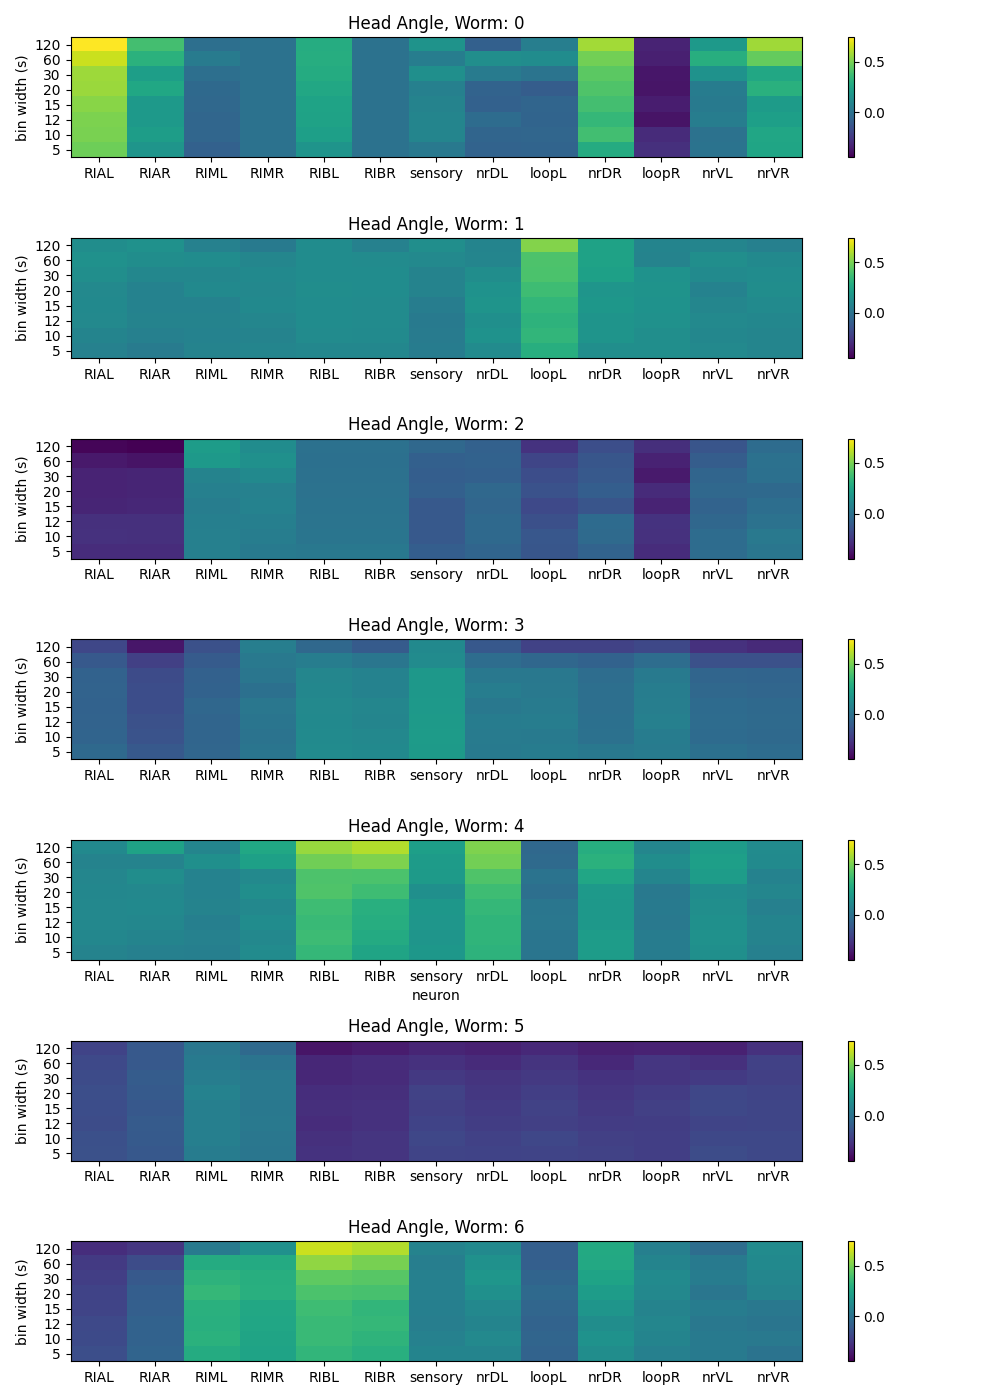

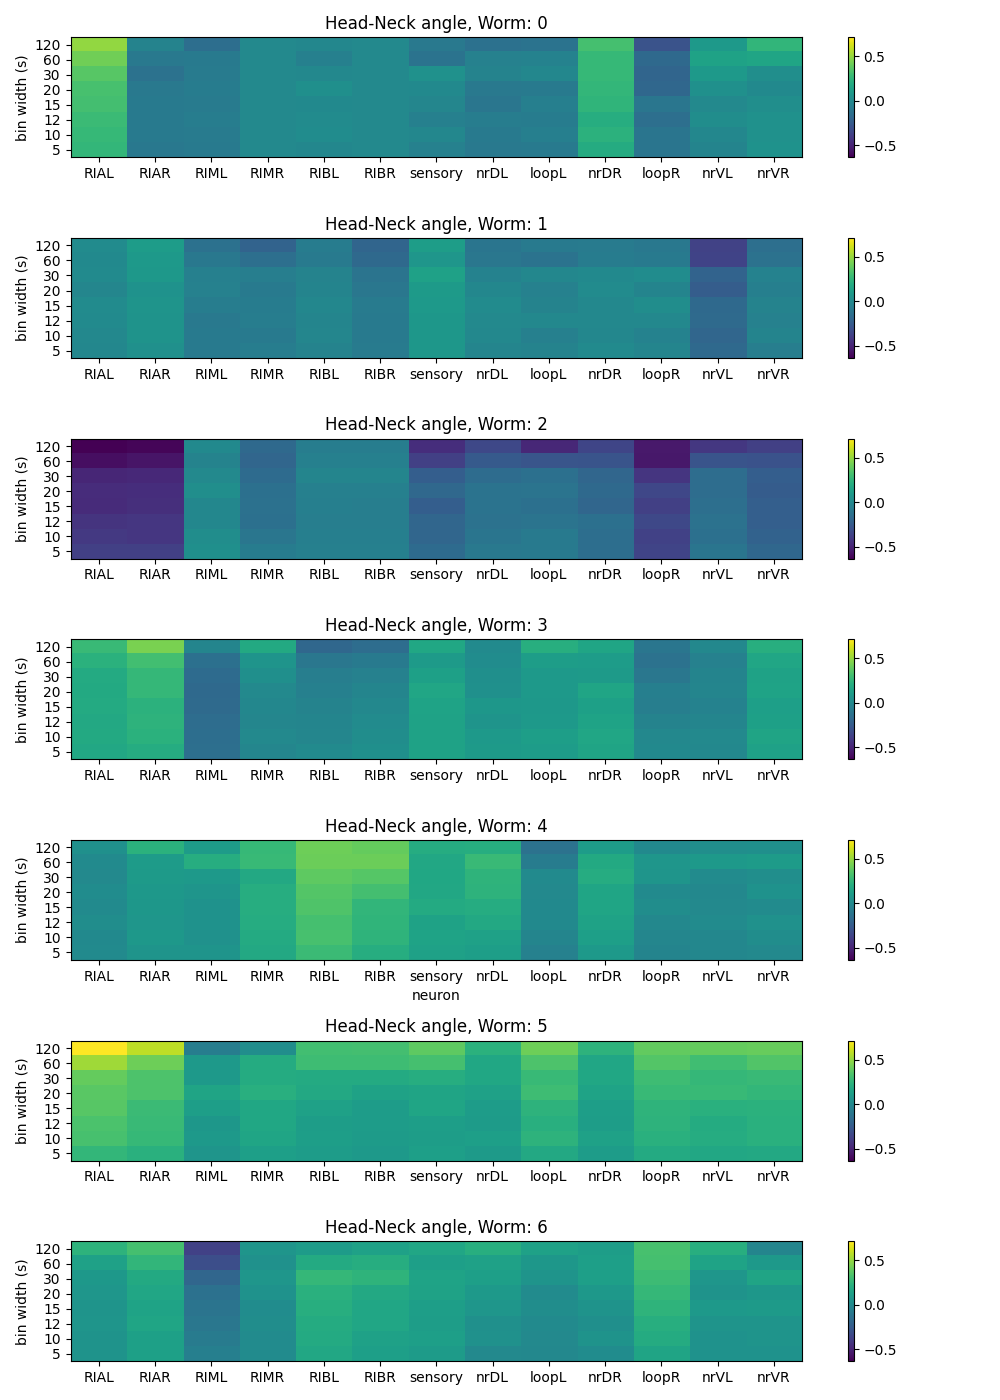

In [56]:
fig, axs = plt.subplots(numW,1, figsize=(10, 2*numW))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_head)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Head Velocity, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(numW,1, figsize=(10, 2*numW))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_headAngle)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = corr_neuronsRI_ind_headAngle[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Head Angle, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(numW,1, figsize=(10, 2*numW))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_headAngle2)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = corr_neuronsRI_ind_headAngle2[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Head-Neck angle, Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

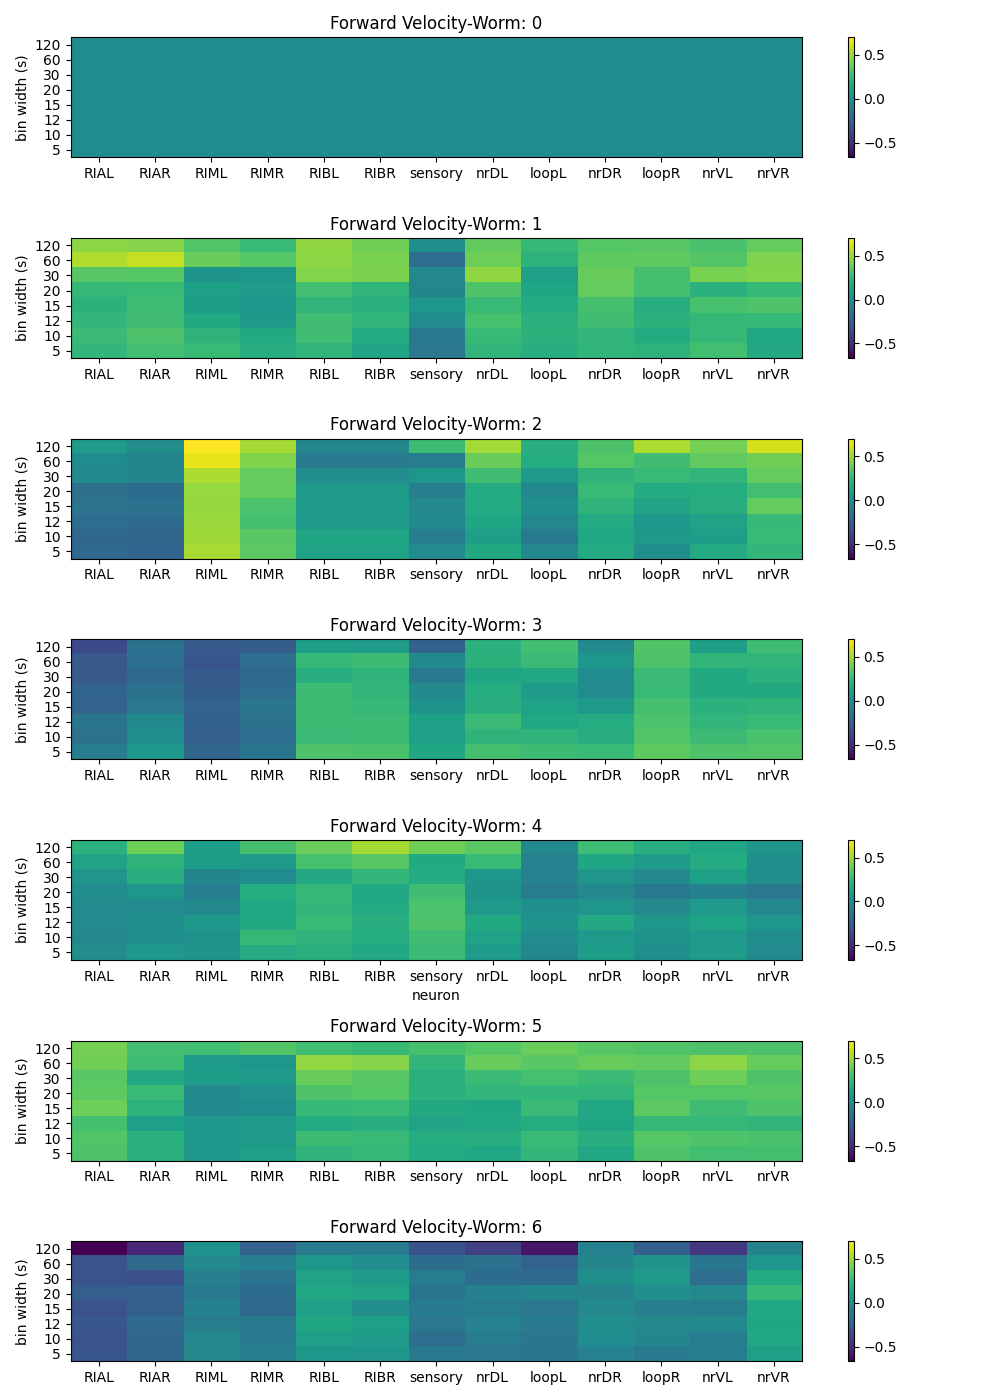

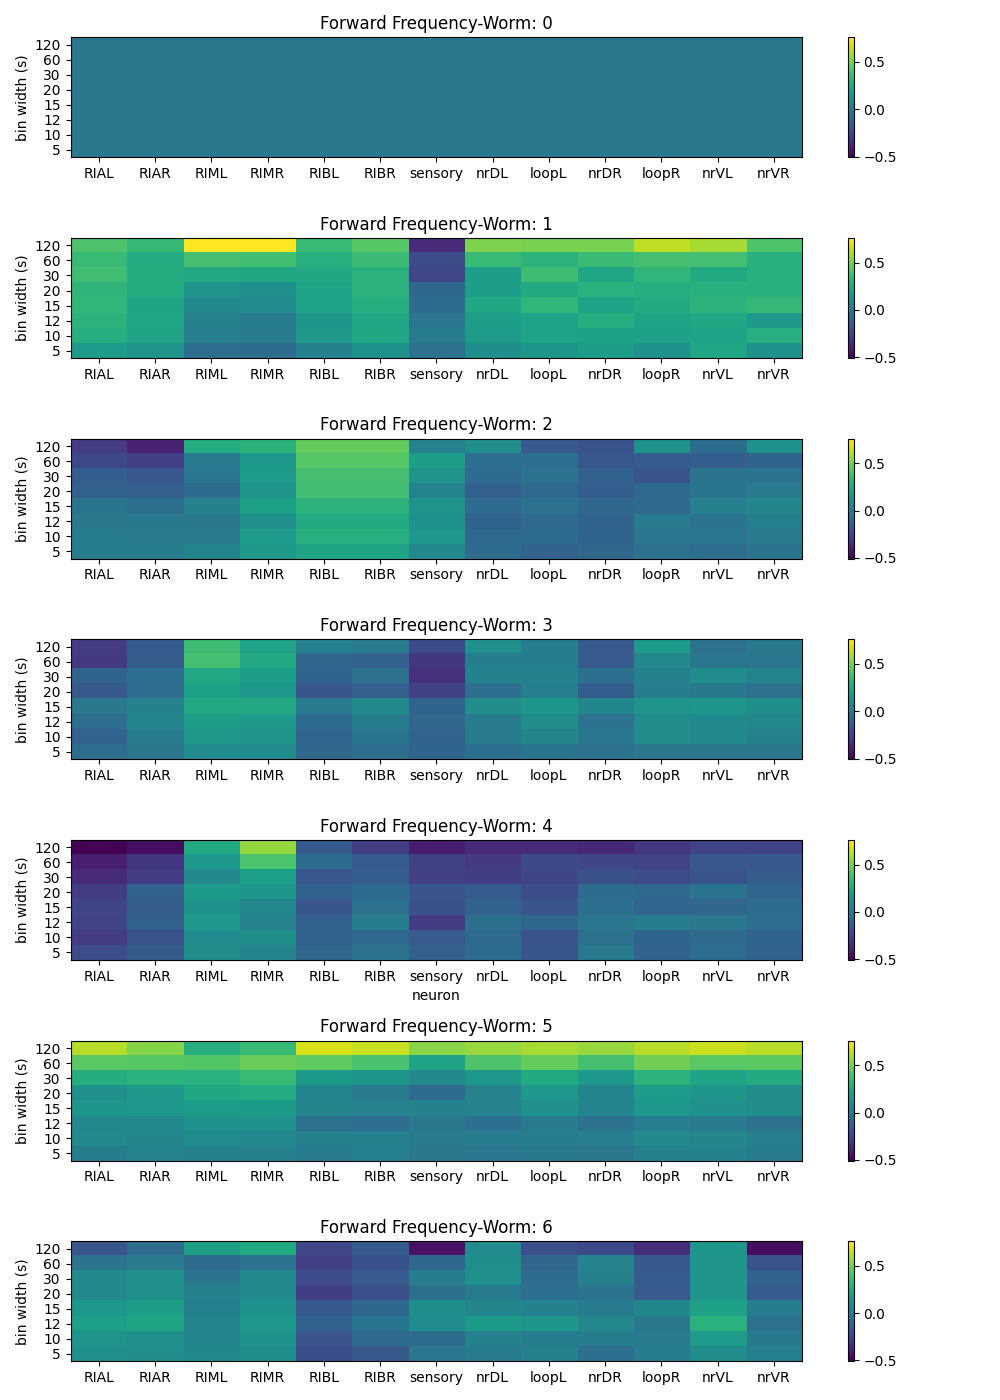

In [57]:
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_Forward)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Forward Velocity-Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_ForwardFreq)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Forward Frequency-Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

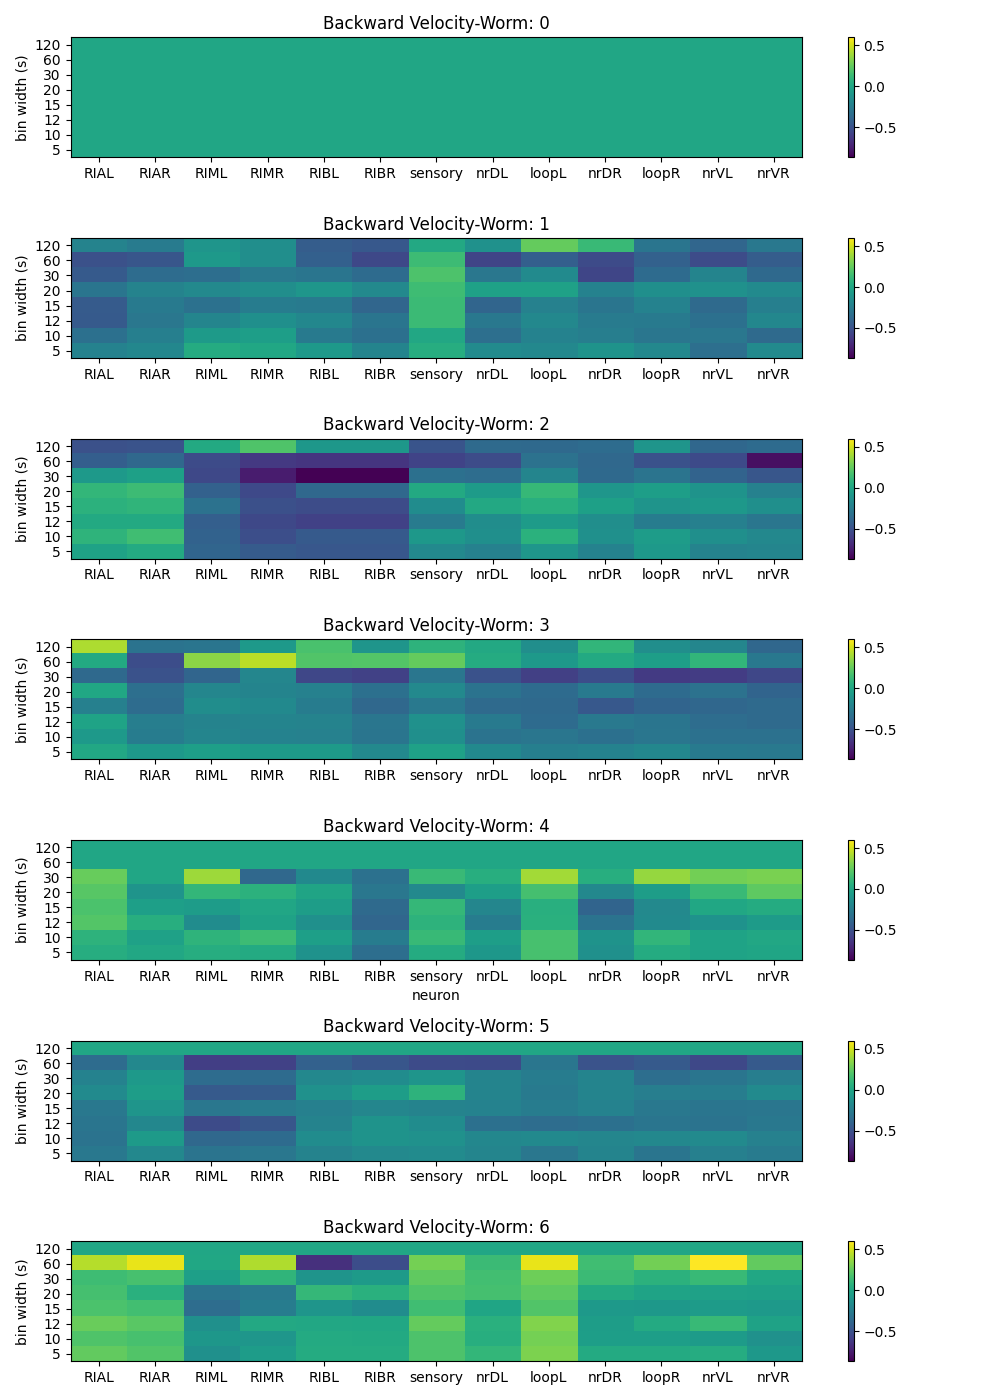

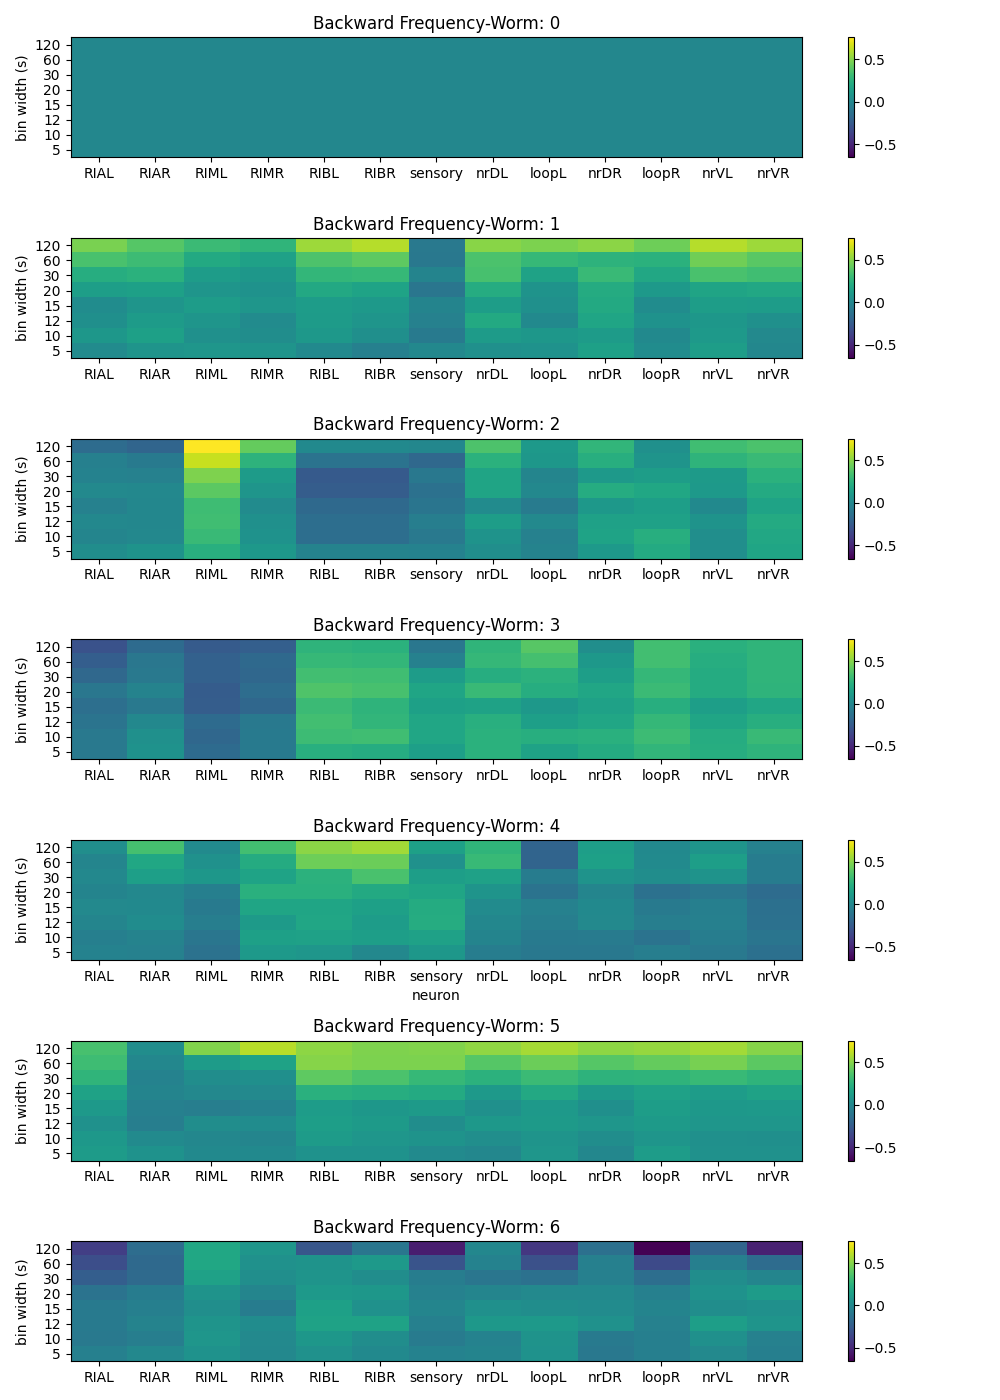

In [58]:
%matplotlib widget
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_Back)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Backward Velocity-Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()


%matplotlib widget
CorrMat = copy.deepcopy(corr_neuronsRI_ind_BackFreq)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Backward Frequency-Worm: '+ str(d)
    axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

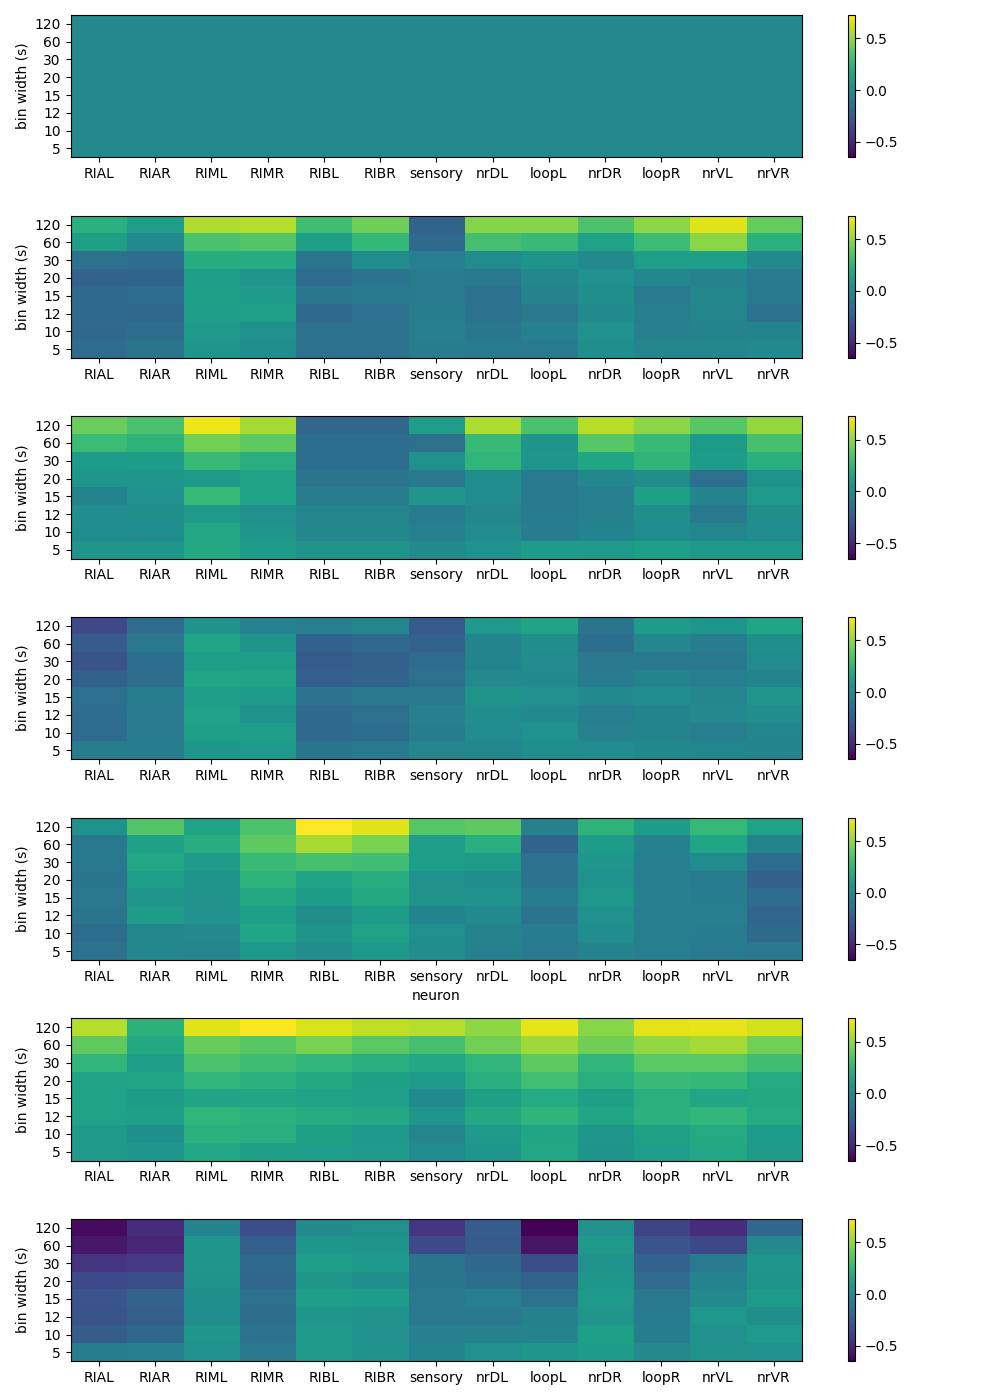

In [33]:
fig, axs = plt.subplots(numW,1, figsize=(10, numW*2))
CorrMat = copy.deepcopy(corr_neuronsRI_ind_turn)
all_min, all_max = np.min(CorrMat),np.max(CorrMat)
for d in range(numW):
    matrix = CorrMat[:,d,:]
    cax1 = axs[d].imshow(matrix, cmap='viridis', aspect='auto',vmin=all_min,vmax=all_max)
    fig.colorbar(cax1, ax=axs[d])
    title = 'Turn, Worm: '+ str(d)
    #axs[d].set_title(title)
    axs[d].set_ylabel('bin width (s)')
    axs[4].set_xlabel('neuron')
    axs[d].set_xticks(np.arange(len(x_labels)))
    axs[d].set_xticklabels(x_labels)
    axs[d].set_yticks(np.arange(len(y_labels)))
    axs[d].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

# heat map of correlations among neurons and neurites at different bin sizes

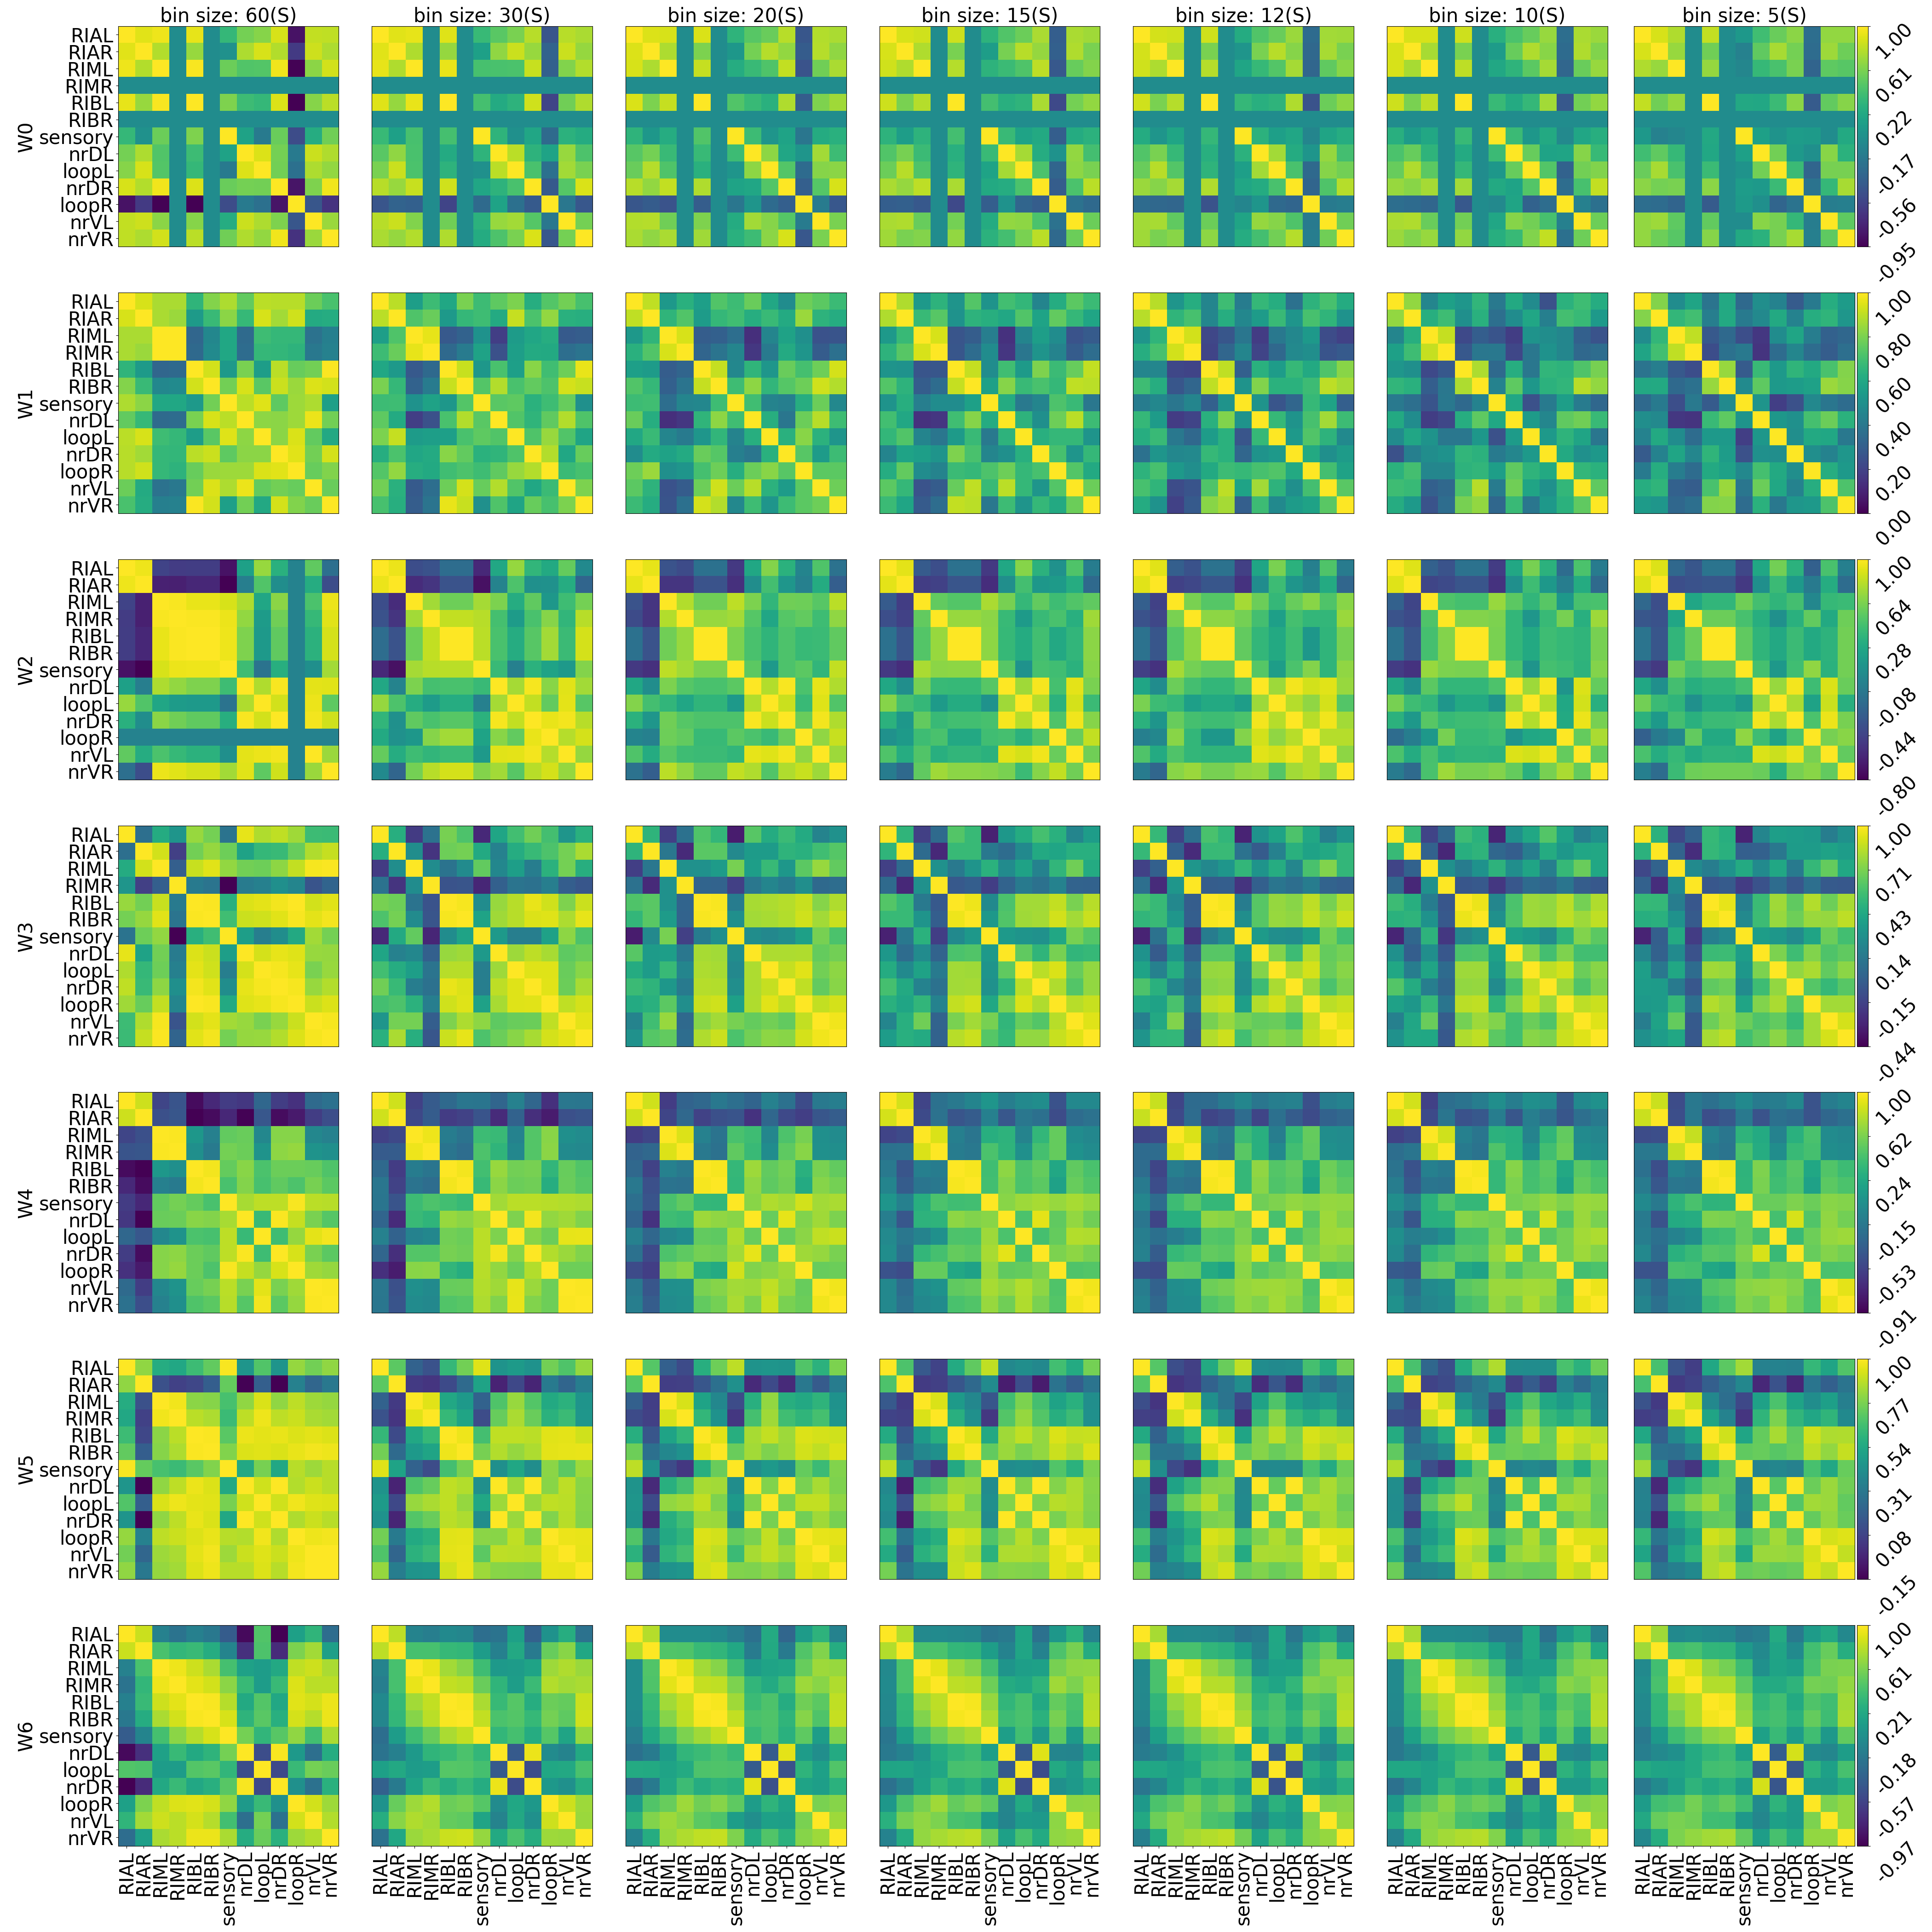

In [58]:
#plot correlations of all neurons with each other in all worms 
fig, axs = plt.subplots(numW,len(bin_coeff), figsize=(len(bin_coeff)*6, 6*numW))
for d in range(numW):
    all_min, all_max = np.min(corr_neuronsRI_ind[:,d,:,:]),np.max(corr_neuronsRI_ind[:,d,:,:])
    for m in range(len(bin_coeff)):
        matrix = corr_neuronsRI_ind[m,d,:,:]
        cax1 = axs[d,m].imshow(matrix, cmap='viridis', vmin=all_min, vmax=all_max)
        if m==(len(bin_coeff)-1):
            divider = make_axes_locatable(axs[d, m])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = fig.colorbar(cax1, cax=cax)
            cbar.ax.tick_params(labelsize=30, rotation=45)
            cbar.set_ticks(np.linspace(all_min, all_max, num=6))  # You can adjust the number of ticks
            cbar.set_ticklabels([f'{tick:.2f}' for tick in np.linspace(all_min, all_max, num=6)])
        title = 'Worm: '+ str(d)
        #axs[d,m].set_title(title)
        if m == 0:
            axs[d,m].set_ylabel('W'+str(d),fontsize=30)
        if d==0:
            axs[d,m].set_title('bin size: '+y_labels[m]+'(S)',fontsize=30)
        if d==6:
            axs[d,m].set_xticks(np.arange(len(x_labels)))
            axs[d,m].set_xticklabels(x_labels,rotation=90)
            axs[d,m].tick_params(axis='x', labelsize=30)
        else:
            axs[d, m].set_xticks([]) 
        if m==0:    
            axs[d,m].set_yticks(np.arange(len(x_labels)))
            axs[d,m].set_yticklabels(x_labels,rotation=00)
            # Adjust rotation if needed
            axs[d,m].tick_params(axis='y', labelsize=30)
        else:
            axs[d, m].set_yticks([]) 

plt.tight_layout()
plt.show()

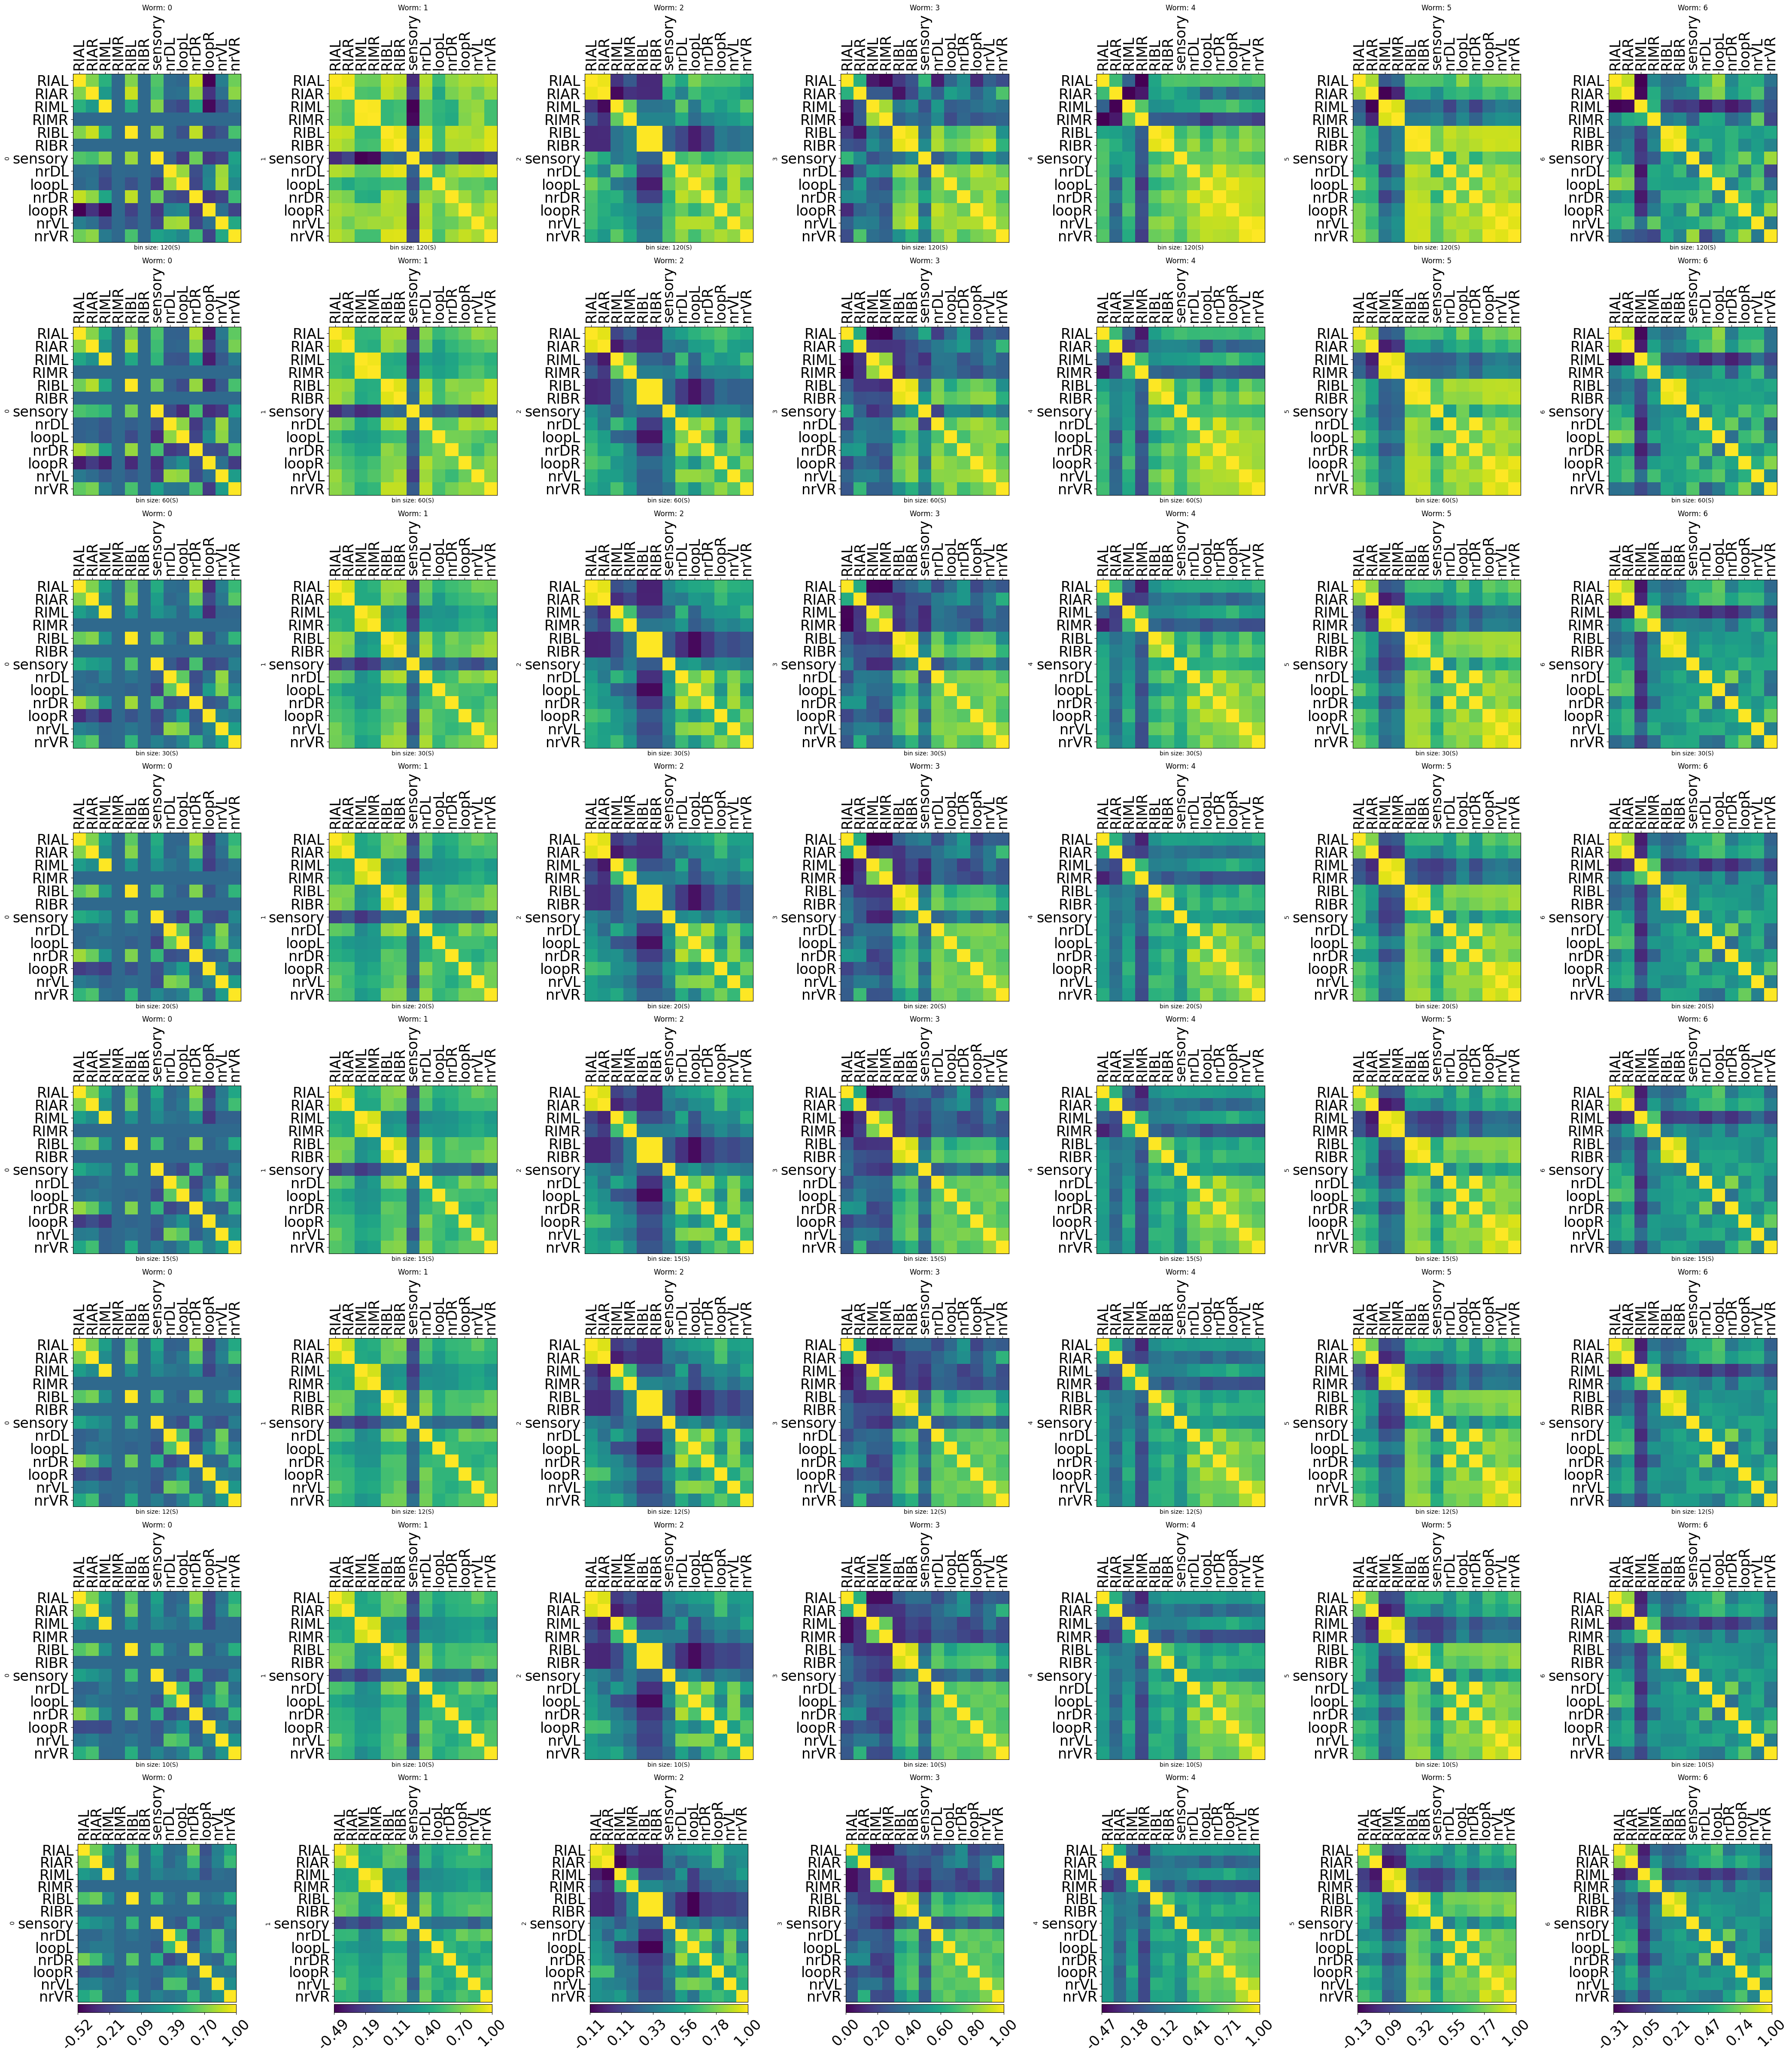

In [19]:
#plot correlations of all neurons with each other in all worms-rotated
fig, axs = plt.subplots(len(bin_coeff),numW, figsize=(6*numW,len(bin_coeff)*6))
for d in range(numW):
    all_min, all_max = np.min(corr_neuronsRI_ind[:,d,:,:]),np.max(corr_neuronsRI_ind[:,d,:,:])
    for m in range(len(bin_coeff)):
        matrix = corr_neuronsRI_ind[m,d,:,:]
        cax1 = axs[m,d].imshow(matrix, cmap='viridis', vmin=all_min, vmax=all_max)
        if m==(len(bin_coeff)-1):
            divider = make_axes_locatable(axs[m,d])
            cax = divider.append_axes("bottom", size="5%", pad=0.05)
            cbar = fig.colorbar(cax1, cax=cax,orientation='horizontal')
            cbar.ax.tick_params(labelsize=24, rotation=45)
            cbar.set_ticks(np.linspace(all_min, all_max, num=6))  # You can adjust the number of ticks
            cbar.set_ticklabels([f'{tick:.2f}' for tick in np.linspace(all_min, all_max, num=6)])
        title = 'Worm: '+ str(d)
        axs[m,d].set_title(title)
        axs[m,d].set_ylabel(str(d))
        axs[m,d].set_xlabel('bin size: '+y_labels[m]+'(S)')
        axs[m,d].set_xticks(np.arange(len(x_labels)))
        axs[m,d].set_xticklabels(x_labels,rotation=90)
        axs[m,d].set_yticks(np.arange(len(x_labels)))
        axs[m,d].set_yticklabels(x_labels,rotation=00)
        axs[m,d].tick_params(axis='x', labelsize=24)  # Adjust rotation if needed
        axs[m,d].tick_params(axis='y', labelsize=24)
        axs[m,d].xaxis.tick_top()

plt.tight_layout()
plt.show()

/tmp/ipykernel_48410/2146375891.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


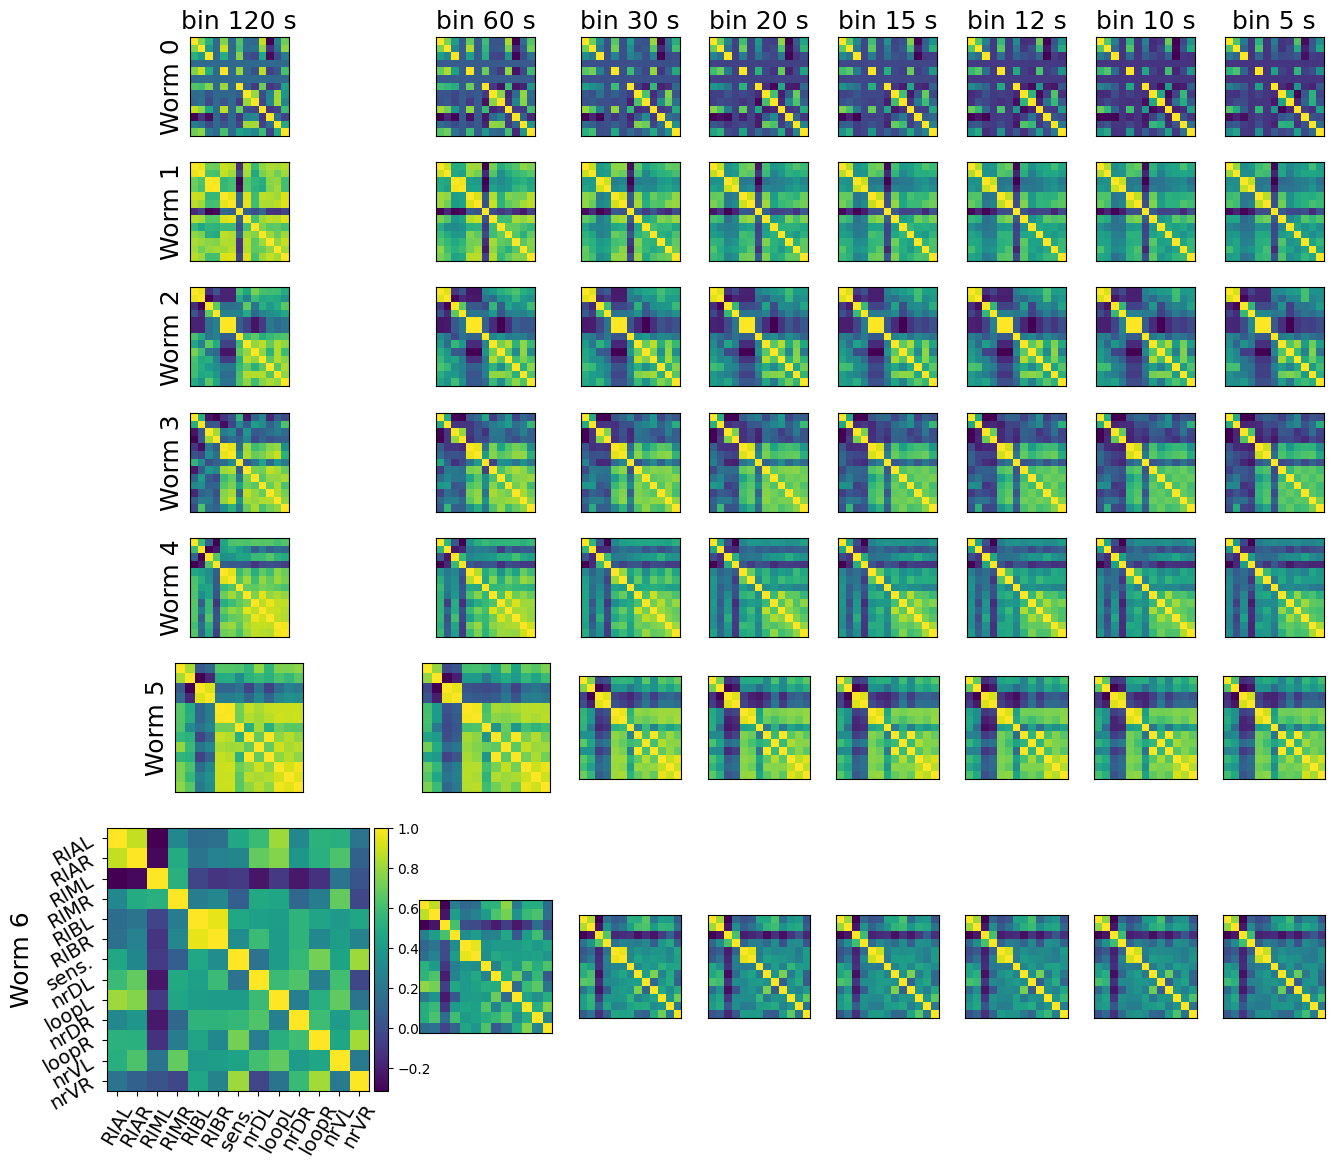

In [20]:
num_bins = len(bin_coeff)
center_row, center_col = numW-1,0#numW // 2, num_bins // 2
x_labels = ['RIAL', 'RIAR', 'RIML', 'RIMR', 'RIBL', 'RIBR', 'sens.', 
            'nrDL', 'loopL', 'nrDR', 'loopR', 'nrVL', 'nrVR']
# Define larger ratios for center row and column
row_ratios = [1]*numW
row_ratios[center_row] = 3  # make the center row double height
col_ratios = [1]*num_bins
col_ratios[center_col] = 3  # make the center column double width

for r in [center_row - 1, center_row + 1]:
    if r >= 0 and r < numW:
        row_ratios[r] = 1.3
for c in [center_col - 1, center_col + 1]:
    if c >= 0 and c < num_bins:
        col_ratios[c] = 1.3

# Now create figure and GridSpec with small global spacing:
fig = plt.figure(figsize=(num_bins * 2, numW * 2))
gs = gridspec.GridSpec(
    numW, num_bins, 
    figure=fig, 
    width_ratios=col_ratios, 
    height_ratios=row_ratios, 
    wspace=0.2,   # small for most plots
    hspace=0.2
)



for d in range(numW):
    for m in range(num_bins):
        ax = fig.add_subplot(gs[d, m])
        matrix = corr_neuronsRI_ind[m,d,:,:]
        
        cax = ax.imshow(matrix, cmap='viridis')
        
        # Add tick labels only to the center big plot (since that cell is larger)
        if d == center_row and m == center_col:
            pos = ax.get_position()  # get current position [x0, y0, width, height]
            new_pos = [pos.x0 + 0.01, pos.y0 + 0.01, pos.width - 0.01, pos.height - 0.01] 
            ax.set_position(new_pos)
            ax.set_xticks(np.arange(len(x_labels)))
            ax.set_xticklabels(x_labels, rotation=60, fontsize=14)
            ax.set_yticks(np.arange(len(x_labels)))
            ax.set_yticklabels(x_labels, rotation=30, fontsize=14)
            #ax.set_xlabel('Neuron', fontsize=14)
            #ax.set_ylabel('Bin width (s)', fontsize=14)
            #ax.set_title(f"Worm {d}, bin {y_labels[m]} s", fontsize=18)
            if m==0:
                ax.set_ylabel(f"Worm {d}", fontsize=18)
            # Optional: add a colorbar only for center plot
            from mpl_toolkits.axes_grid1 import make_axes_locatable
            divider = make_axes_locatable(ax)
            cax_cb = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(cax, cax=cax_cb)
        else:
            # Small plots: no ticks
            ax.set_xticks([])
            ax.set_yticks([])
            if m==0:
                ax.set_ylabel(f"Worm {d}", fontsize=18)
            if d==0:    
                ax.set_title(f"bin {y_labels[m]} s", fontsize=18)

plt.tight_layout(pad=2.0)
plt.show()

# Average correlations of all neurons as a function of binsize. Histogram of neuronal correlations

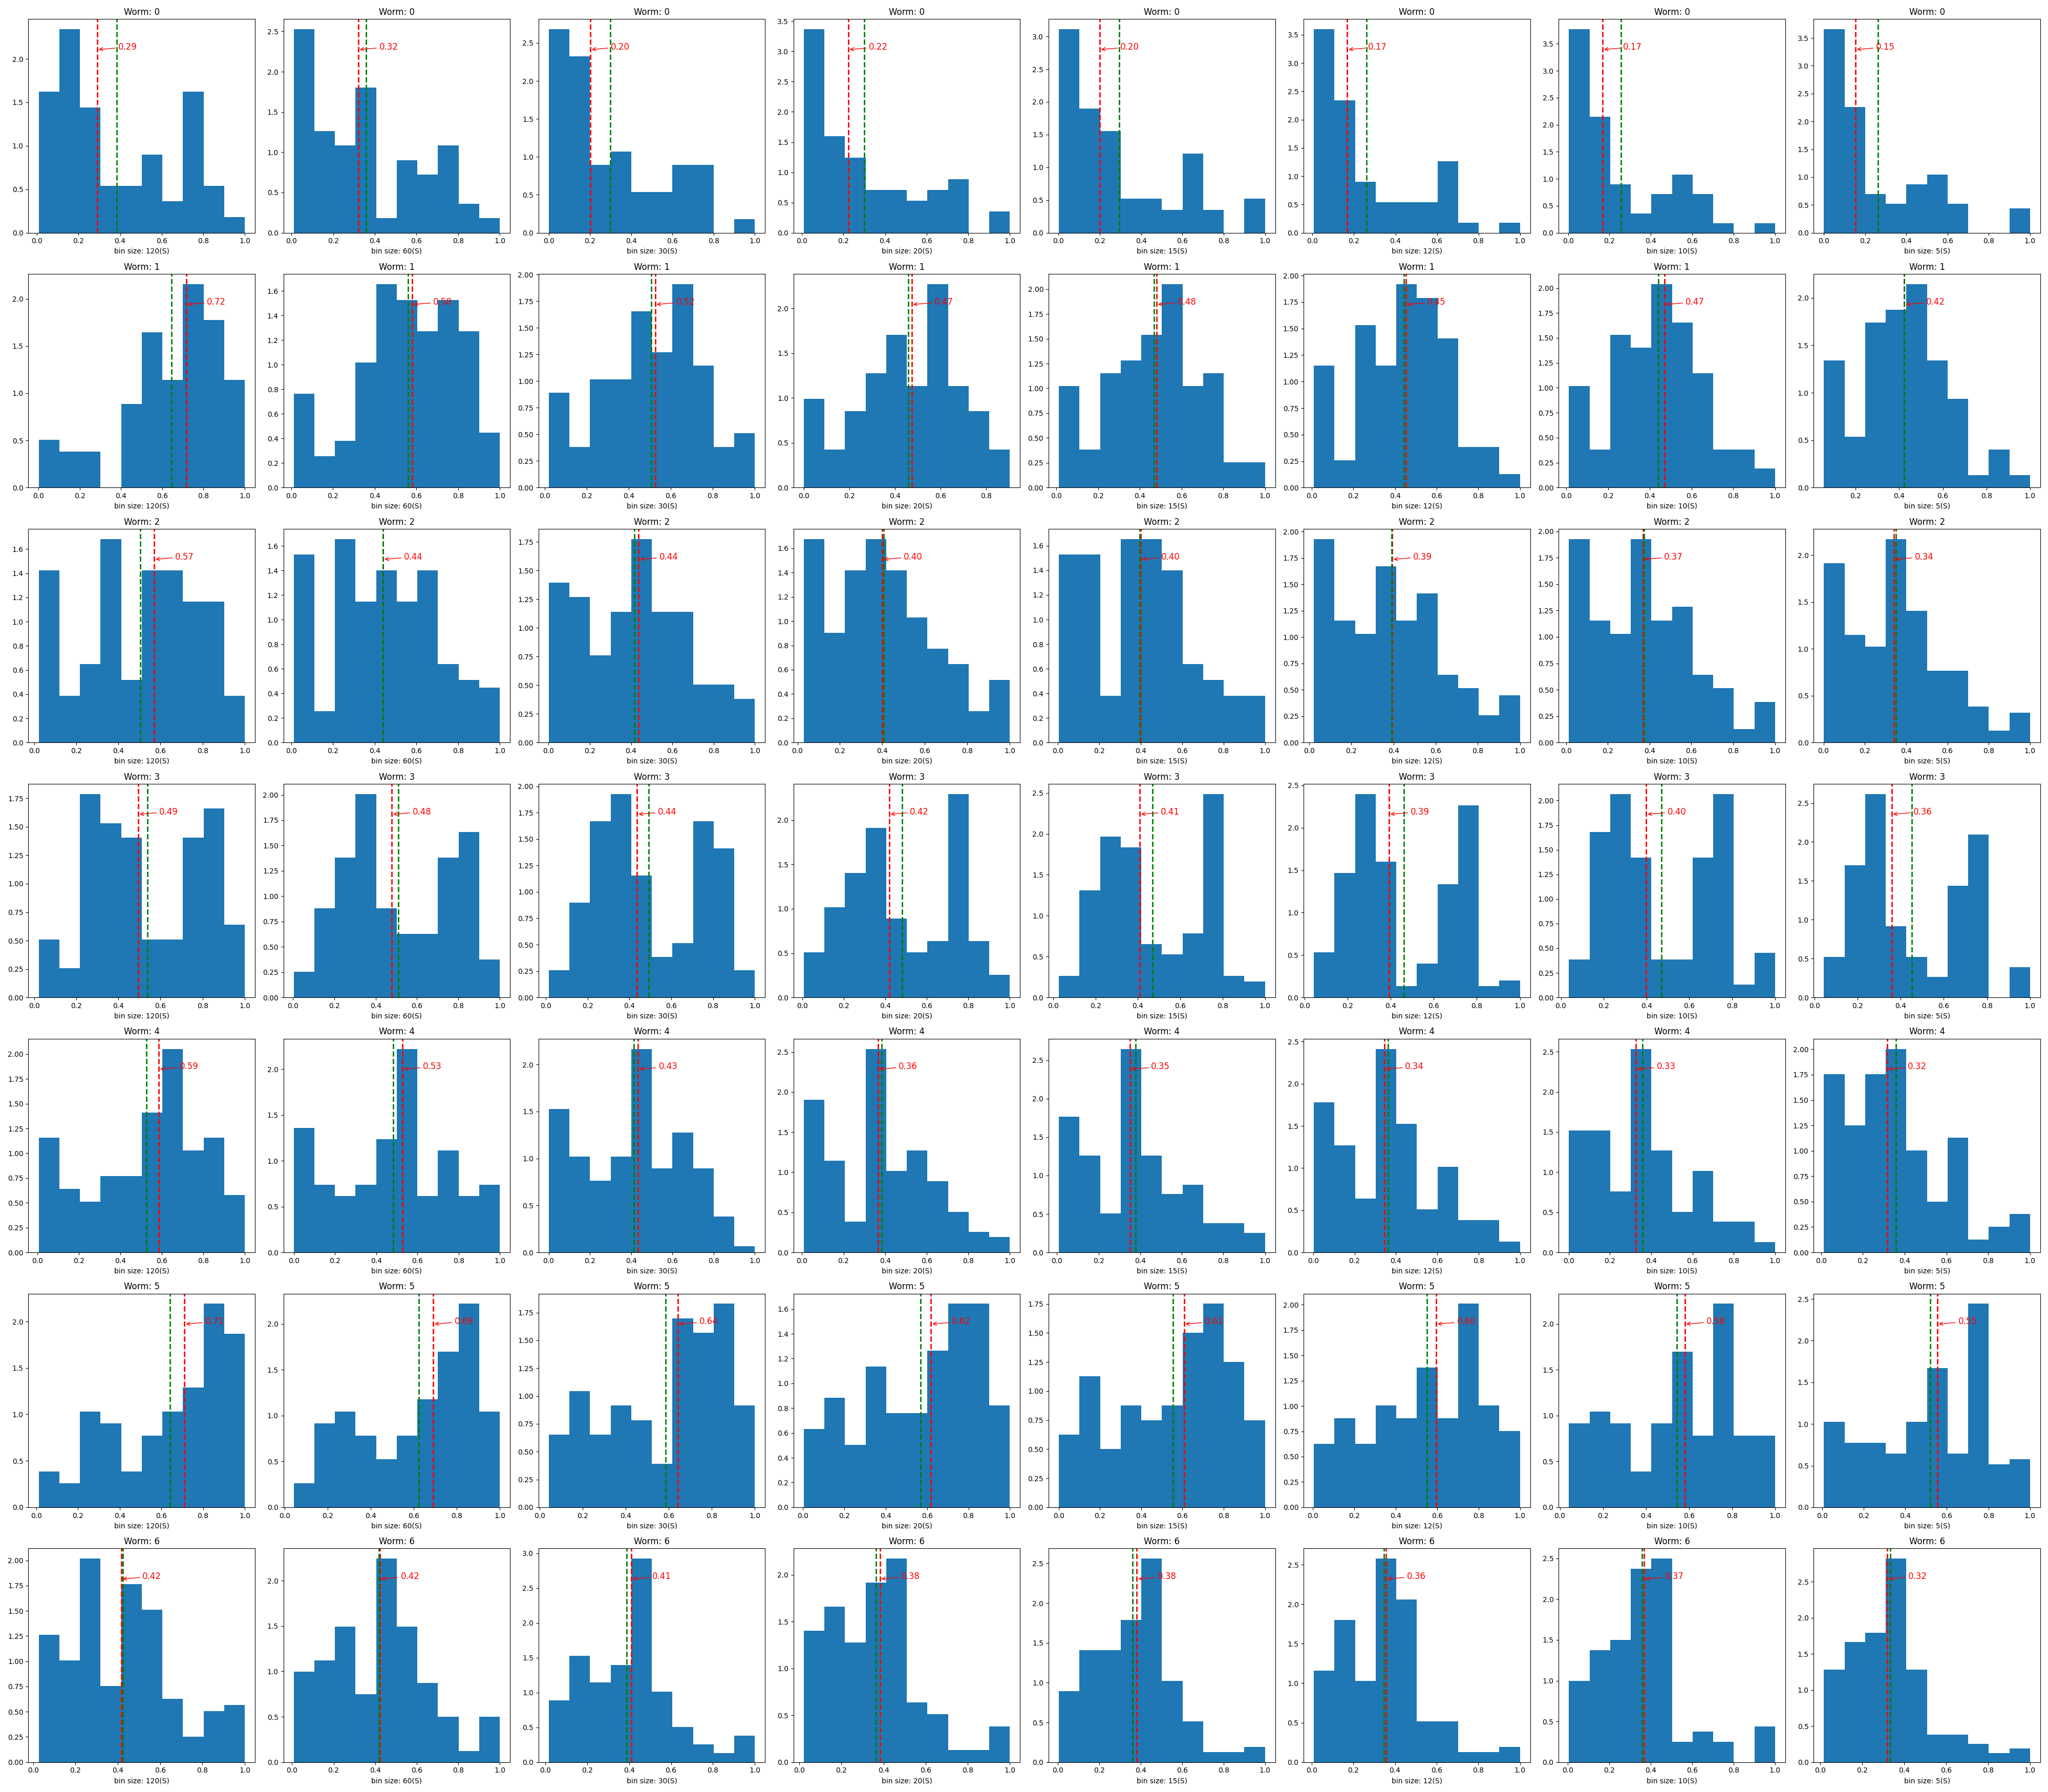

In [27]:
#distribution of neurons correlation at each bin and each worm. median is marked
fig, axs = plt.subplots(numW,len(bin_coeff), figsize=(len(bin_coeff)*5, numW*5))
medianvalues = np.zeros((numW,len(bin_coeff)))
meanvalues = np.zeros((numW,len(bin_coeff)))
for d in range(numW):
    for m in range(len(bin_coeff)):
        matrix = corr_neuronsRI_ind[m,d,:,:]
        data = np.abs(matrix.flatten())
        data = data[data != 1]#throw 1 values
        data = data[data != 0]#throw 0 values
        counts, bins, patches = axs[d,m].hist(data, density=True)
        peak = bins[np.argmax(counts)]
        
        peak_index = np.argmax(counts)
        peak_center = (bins[peak_index] + bins[peak_index + 1]) / 2
        median_value = np.median(data)
        medianvalues[d,m]=median_value
        meanvalues[d,m]=np.mean(data)
        # Plot a vertical line at the median value
        axs[d,m].axvline(median_value, color='red', linestyle='--', linewidth=2, label='Median')
        axs[d,m].axvline(meanvalues[d,m], color='green', linestyle='--', linewidth=2, label='Median')
        axs[d,m].annotate(f'{median_value:.2f}', xy=(median_value, 0.9 * max(counts)),
                        xytext=(median_value + 0.1, 0.9 * max(counts)),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        color='red', fontsize=12)
        title = 'Worm: '+ str(d)
        axs[d,m].set_title(title)

        axs[d,m].set_xlabel('bin size: '+y_labels[m]+'(S)')


plt.tight_layout()
plt.show()

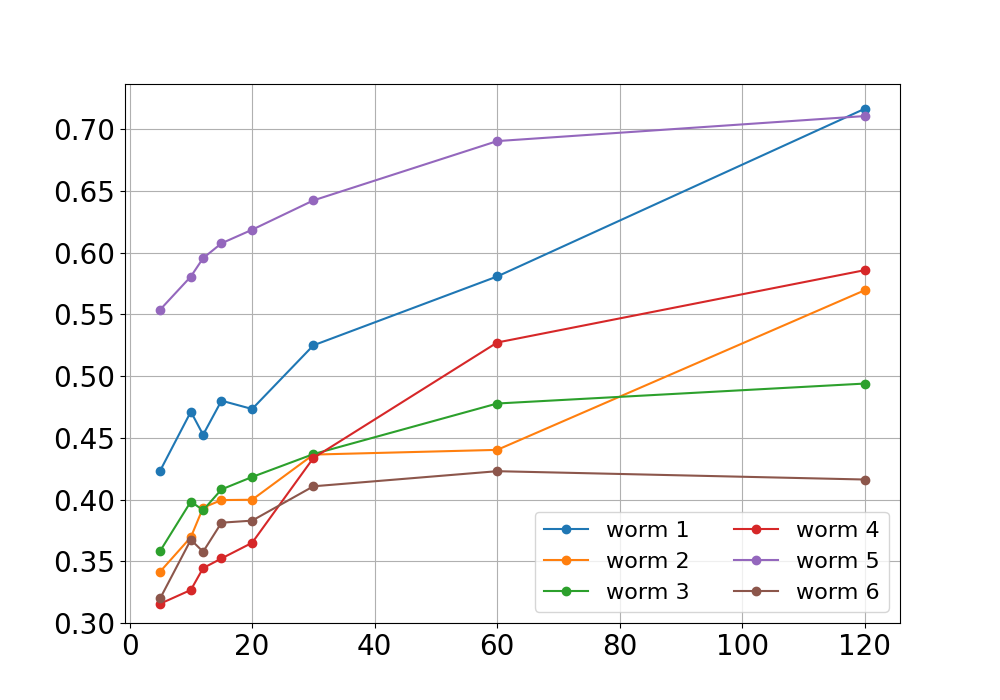

In [28]:
#plot median of corelations
medianvalues[d,m]
plt.figure(figsize=(10, 7))
for i in range(1,numW):
    plt.plot(timebins,medianvalues[i, :], marker='o', label=f'worm {i}')
plt.xticks(fontsize=20)  # Adjust x-axis tick size
plt.yticks(fontsize=20) 
plt.legend(fontsize=16,ncol=2)
plt.ylim(bottom=0.3)
plt.grid(True)

plt.show()

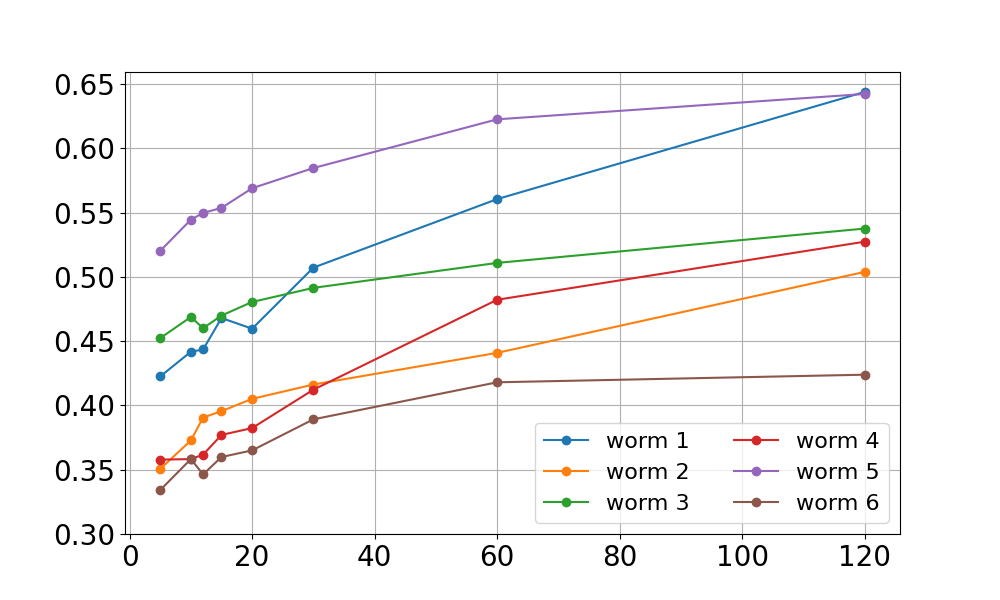

In [30]:
plt.figure(figsize=(10, 6))
for i in range(1,numW):
    plt.plot(timebins,meanvalues[i, :], marker='o', label=f'worm {i}')

plt.xticks(fontsize=20)  # Adjust x-axis tick size
plt.yticks(fontsize=20) 
plt.legend(fontsize=16,ncol=2)
plt.ylim(bottom=0.30)
plt.grid(True)
plt.show()